# Evaluation
In this final notebook we will evaluate the models' classifications by visualizing the data within the ``results`` dictionary.

## Custom Modules
The ``src`` directory houses custom modules with functions that will be reused throughout the project.

To be able to import these moduls, we begin with programmatically adding the project's root directory to ``sys.path``.

After adding the root to ``sys.path``, we can import the ``data`` and ``util`` modules:

In [1]:
import os, sys

# recursively search for the root directory containing a specific file
def find_root_dir(search_for='.gitignore'):

    current_dir = os.getcwd()

    while True:
        if os.path.exists(os.path.join(current_dir, search_for)):
            return current_dir
        parent_dir = os.path.dirname(current_dir)
        if parent_dir == current_dir:
            raise FileNotFoundError(f"Could not find '{search_for}' in any parent directory.")
        current_dir = parent_dir


# save the root directory to a variable
root_dir = find_root_dir()
print(f"Root directory found: {root_dir}")

# add the root directory to the system path
sys.path.append(root_dir)
if root_dir in sys.path:
    print(f"Root directory added to system path.")


# import custom modules
from src import data

Root directory found: d:\automated_title_abstract_screening
Root directory added to system path.


## Preparation
### Imports

### Warnings
Hide a warning which is normally shown if any bootstrap score should equal zero.

In [2]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

### Definitions
To programmatically access datasets, estimators, together with their pretty printed form, and function calls for computing metrics.

In [3]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, fbeta_score
from imblearn.metrics import specificity_score

# lists of the datasets and estimators used in the analysis
datasets = [
    'animal_depression',
    'adhd',
    'atypical_antipsychotics',
    'calcium_channel_blockers',
    'oral_hypoglycemics'
]

estimators = [
    'logistic_regression',
    'random_forest',
    'support_vector_machine',
    'naive_bayes',
    'llama'
]

# function calls to compute the metrics
metrics = {
    'accuracy': accuracy_score,
    'precision': precision_score,
    'recall': recall_score,
    'f1': f1_score,
    'f2': fbeta_score,
    'specificity': specificity_score,

}

# for pretty printing the estimator and dataset names
estimator_dict = {
    'logistic_regression': 'Logistic Regression',
    'random_forest': 'Random Forest',
    'support_vector_machine': 'Support Vector Machine',
    'naive_bayes': 'Complement Naive Bayes',
    'llama': 'Llama-3.1-8B-Instruct'
}

dataset_dict = {
    'adhd': 'ADHD',
    'animal_depression': 'Animal Depression',
    'atypical_antipsychotics': 'Atypical Antipsychotics',
    'calcium_channel_blockers': 'Calcium Channel Blockers',
    'oral_hypoglycemics': 'Oral Hypoglycemics',
}

estimator_labels = list(map(estimator_dict.get, estimators))
dataset_labels = list(map(dataset_dict.get, datasets))

### Loading the Data
Load the file containing all the results:

In [4]:
import pickle  # to load the pickled results dictionary

with open('./results.pkl', 'rb') as f:
    results = pickle.load(f)

# Inspection
Remember that ``results.pkl`` contains a dictionary that captures:

- one table that summarizes calculated scores with confidence intervals for every combination of dataset and estimator
- for every combination of dataset and estimator
    - a classification report (sklearn.metrics.classification_report)
    - an absolute and a normalized confusion matrix each
    - the bootstrap samples by which the scores were calculated
    - the single bootstrap scores per metric by which the means and confidence intervals have been calculated

The ``results`` dictionary can be accessed through (nested) keys.
When navigating the dictionary remember its structure:

```
└── scores
    └── Polars.DataFrame
└── datasets
    └── dataset
        └── estimator
            ├── classification_report
            |   └── sklearn.metrics.classification_report
            ├── matrix
            |   └── absolute
                    └── sklearn.metrics.confusion_matrix
                └── norm
                    └──sklearn.metrics.confusion_matrix        
            └── bootstrap
                ├── samples
                |   └── List[Tuple[List[y_true]List[y_pred]]]
                └── scores
                    ├── accuracy
                    |   └── List[bootstrap scores]
                    ├── precision
                    |   └── List[bootstrap scores]
                    ├── recall
                    |   └── List[bootstrap scores]
                    └── f1
                        └── List[bootstrap scores]
                    └── f2
                        └── List[bootstrap scores]
                    └── specificity
                        └── List[bootstrap scores]




```

## Scores
The scores table contains the means and confidence intervals (mean, lower bound, upper bound) for score and each combination of dataset and estimator.

In [5]:
results['datasets'].keys()

dict_keys(['adhd', 'animal_depression', 'atypical_antipsychotics', 'calcium_channel_blockers', 'oral_hypoglycemics'])

In [6]:
scores = results['scores']
scores

dataset,estimator,accuracy,precision,recall,f1,f2,specificity
str,str,struct[3],struct[3],struct[3],struct[3],struct[3],struct[3]
"""adhd""","""logistic_regression""","{0.88,0.84,0.92}","{0.15,0.04,0.29}","{0.83,0.5,1.0}","{0.26,0.07,0.43}","{0.43,0.14,0.64}","{0.88,0.84,0.92}"
"""adhd""","""random_forest""","{0.89,0.85,0.92}","{0.14,0.03,0.27}","{0.66,0.25,1.0}","{0.22,0.06,0.4}","{0.36,0.11,0.59}","{0.89,0.85,0.93}"
"""adhd""","""support_vector_machine""","{0.91,0.88,0.95}","{0.2,0.06,0.36}","{0.83,0.43,1.0}","{0.32,0.1,0.52}","{0.49,0.19,0.71}","{0.91,0.88,0.95}"
"""adhd""","""naive_bayes""","{0.64,0.58,0.7}","{0.06,0.01,0.12}","{1.0,1.0,1.0}","{0.12,0.03,0.21}","{0.24,0.06,0.4}","{0.63,0.57,0.69}"
"""adhd""","""llama""","{0.81,0.76,0.86}","{0.12,0.04,0.22}","{1.0,1.0,1.0}","{0.21,0.07,0.36}","{0.39,0.16,0.58}","{0.81,0.76,0.86}"
…,…,…,…,…,…,…,…
"""oral_hypoglycemics""","""logistic_regression""","{0.71,0.63,0.78}","{0.45,0.31,0.6}","{0.58,0.42,0.74}","{0.51,0.37,0.63}","{0.55,0.4,0.68}","{0.75,0.67,0.84}"
"""oral_hypoglycemics""","""random_forest""","{0.63,0.55,0.71}","{0.38,0.27,0.5}","{0.67,0.51,0.82}","{0.48,0.36,0.6}","{0.58,0.44,0.7}","{0.62,0.52,0.71}"
"""oral_hypoglycemics""","""support_vector_machine""","{0.78,0.7,0.84}","{0.58,0.41,0.76}","{0.52,0.37,0.69}","{0.55,0.41,0.68}","{0.53,0.39,0.68}","{0.86,0.8,0.93}"


By filtering and sorting one can, for example, inspect which estimator achieved the highest recall within the animal depression dataset:

In [7]:
import polars as pl

scores.filter(
    pl.col('dataset') == 'animal_depression'
).sort(
    by='recall',
    descending=True
).select(
    [
        pl.col('estimator'),
        pl.col('recall'),
        pl.col('specificity')
    ]
)

estimator,recall,specificity
str,struct[3],struct[3]
"""naive_bayes""","{0.97,0.93,1.0}","{0.66,0.61,0.7}"
"""llama""","{0.96,0.91,1.0}","{0.83,0.79,0.86}"
"""logistic_regression""","{0.93,0.87,0.99}","{0.91,0.89,0.94}"
"""random_forest""","{0.91,0.83,0.97}","{0.9,0.87,0.93}"
"""support_vector_machine""","{0.9,0.83,0.97}","{0.92,0.9,0.94}"


### Export Scores Table

Here we construct a scores table like the one from the publication.

Begin by reordering and formatting the columns:

In [8]:
# order the columns as wished
scores_table = results['scores'].select(
        [
            'dataset',
            'estimator',
            'recall',
            'specificity',
            'precision',
            'f1',
            'f2',
            'accuracy',
        ]
    ).with_columns( # map dataset and estimator names to their pretty versions
        pl.col('dataset').replace(dataset_dict).alias('dataset'),
        pl.col('estimator').replace(estimator_dict).alias('estimator'),
    )

Next, unnest the metric structs into a single string column, allowing them to export to .csv

In [9]:
# unnest the metric structs into a single string column
for metric in metrics:
    scores_table = scores_table.with_columns(
        pl.concat_str(
            pl.col(metric).struct.field(f'{metric}_mean'),
            pl.lit('\n['),
            pl.col(metric).struct.field(f'{metric}_lower'),
            pl.lit(', '),
            pl.col(metric).struct.field(f'{metric}_upper'),
            pl.lit(']')
        ).alias(metric)
    )

In [10]:
# format the column names to be more readable
scores_table = scores_table.select(
    pl.all().name.map(
        lambda x: x.title()
    )
)

In [11]:
# show the formatted dataframe
scores_table

Dataset,Estimator,Recall,Specificity,Precision,F1,F2,Accuracy
str,str,str,str,str,str,str,str
"""ADHD""","""Logistic Regression""","""0.83 [0.5, 1.0]""","""0.88 [0.84, 0.92]""","""0.15 [0.04, 0.29]""","""0.26 [0.07, 0.43]""","""0.43 [0.14, 0.64]""","""0.88 [0.84, 0.92]"""
"""ADHD""","""Random Forest""","""0.66 [0.25, 1.0]""","""0.89 [0.85, 0.93]""","""0.14 [0.03, 0.27]""","""0.22 [0.06, 0.4]""","""0.36 [0.11, 0.59]""","""0.89 [0.85, 0.92]"""
"""ADHD""","""Support Vector Machine""","""0.83 [0.43, 1.0]""","""0.91 [0.88, 0.95]""","""0.2 [0.06, 0.36]""","""0.32 [0.1, 0.52]""","""0.49 [0.19, 0.71]""","""0.91 [0.88, 0.95]"""
"""ADHD""","""Complement Naive Bayes""","""1.0 [1.0, 1.0]""","""0.63 [0.57, 0.69]""","""0.06 [0.01, 0.12]""","""0.12 [0.03, 0.21]""","""0.24 [0.06, 0.4]""","""0.64 [0.58, 0.7]"""
"""ADHD""","""Llama-3.1-8B-Instruct""","""1.0 [1.0, 1.0]""","""0.81 [0.76, 0.86]""","""0.12 [0.04, 0.22]""","""0.21 [0.07, 0.36]""","""0.39 [0.16, 0.58]""","""0.81 [0.76, 0.86]"""
…,…,…,…,…,…,…,…
"""Oral Hypoglycemics""","""Logistic Regression""","""0.58 [0.42, 0.74]""","""0.75 [0.67, 0.84]""","""0.45 [0.31, 0.6]""","""0.51 [0.37, 0.63]""","""0.55 [0.4, 0.68]""","""0.71 [0.63, 0.78]"""
"""Oral Hypoglycemics""","""Random Forest""","""0.67 [0.51, 0.82]""","""0.62 [0.52, 0.71]""","""0.38 [0.27, 0.5]""","""0.48 [0.36, 0.6]""","""0.58 [0.44, 0.7]""","""0.63 [0.55, 0.71]"""
"""Oral Hypoglycemics""","""Support Vector Machine""","""0.52 [0.37, 0.69]""","""0.86 [0.8, 0.93]""","""0.58 [0.41, 0.76]""","""0.55 [0.41, 0.68]""","""0.53 [0.39, 0.68]""","""0.78 [0.7, 0.84]"""


Next, we export the scores table:

In [12]:
scores_table.write_csv('scores_table.csv')

# Classificaton Reports
The scikit-learn classification report provides the main classification metrics per class, as well as with macro and weighted averages

In [13]:
DATASET = 'animal_depression'
ESTIMATOR = 'llama'

report = results['datasets'][DATASET][ESTIMATOR]['classification_report']
print(report)

              precision    recall  f1-score   support

       False       0.99      0.83      0.90       434
        True       0.49      0.96      0.65        74

    accuracy                           0.85       508
   macro avg       0.74      0.89      0.77       508
weighted avg       0.92      0.85      0.86       508



# Confusion Matrices
A confusion matrix plots each possible class instance against how often it was predicted right- or wrongfully.

### Helper Functions
This helper function takes a confusion matrix and draws it on a given pyplot axis:

In [14]:
from sklearn.metrics import ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

def plot_confusion_matrix(
        matrix: np.ndarray, 
        ax: plt.axis, 
        fontsize: int = 12
    ) -> None:
    """
    Plot a given confusion matrix on a given matplotlib.pyplot.axis

    Args:
        matrix (np.ndarray): The confusion matrix to plot.
        ax (matplotlib.pyplot.axis): The axis to plot the confusion matrix on.
        fontsize (int, optional): Font size for the labels. Defaults to 12.

    Returns:
        None: The function modifies the axis in place to display the confusion matrix.
    """

    disp = ConfusionMatrixDisplay(matrix, display_labels=['Exclude', 'Include'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues', text_kw={'fontsize': fontsize})  
    ax.set_xlabel('Predicted Label', fontsize=fontsize)  
    ax.set_ylabel('True Label', fontsize=fontsize)       
    ax.tick_params(axis='both', which='major', labelsize=fontsize)

### Matrix of Matrices
We begin by plotting confusion matrices for all possible combinations of datasets and estimators:

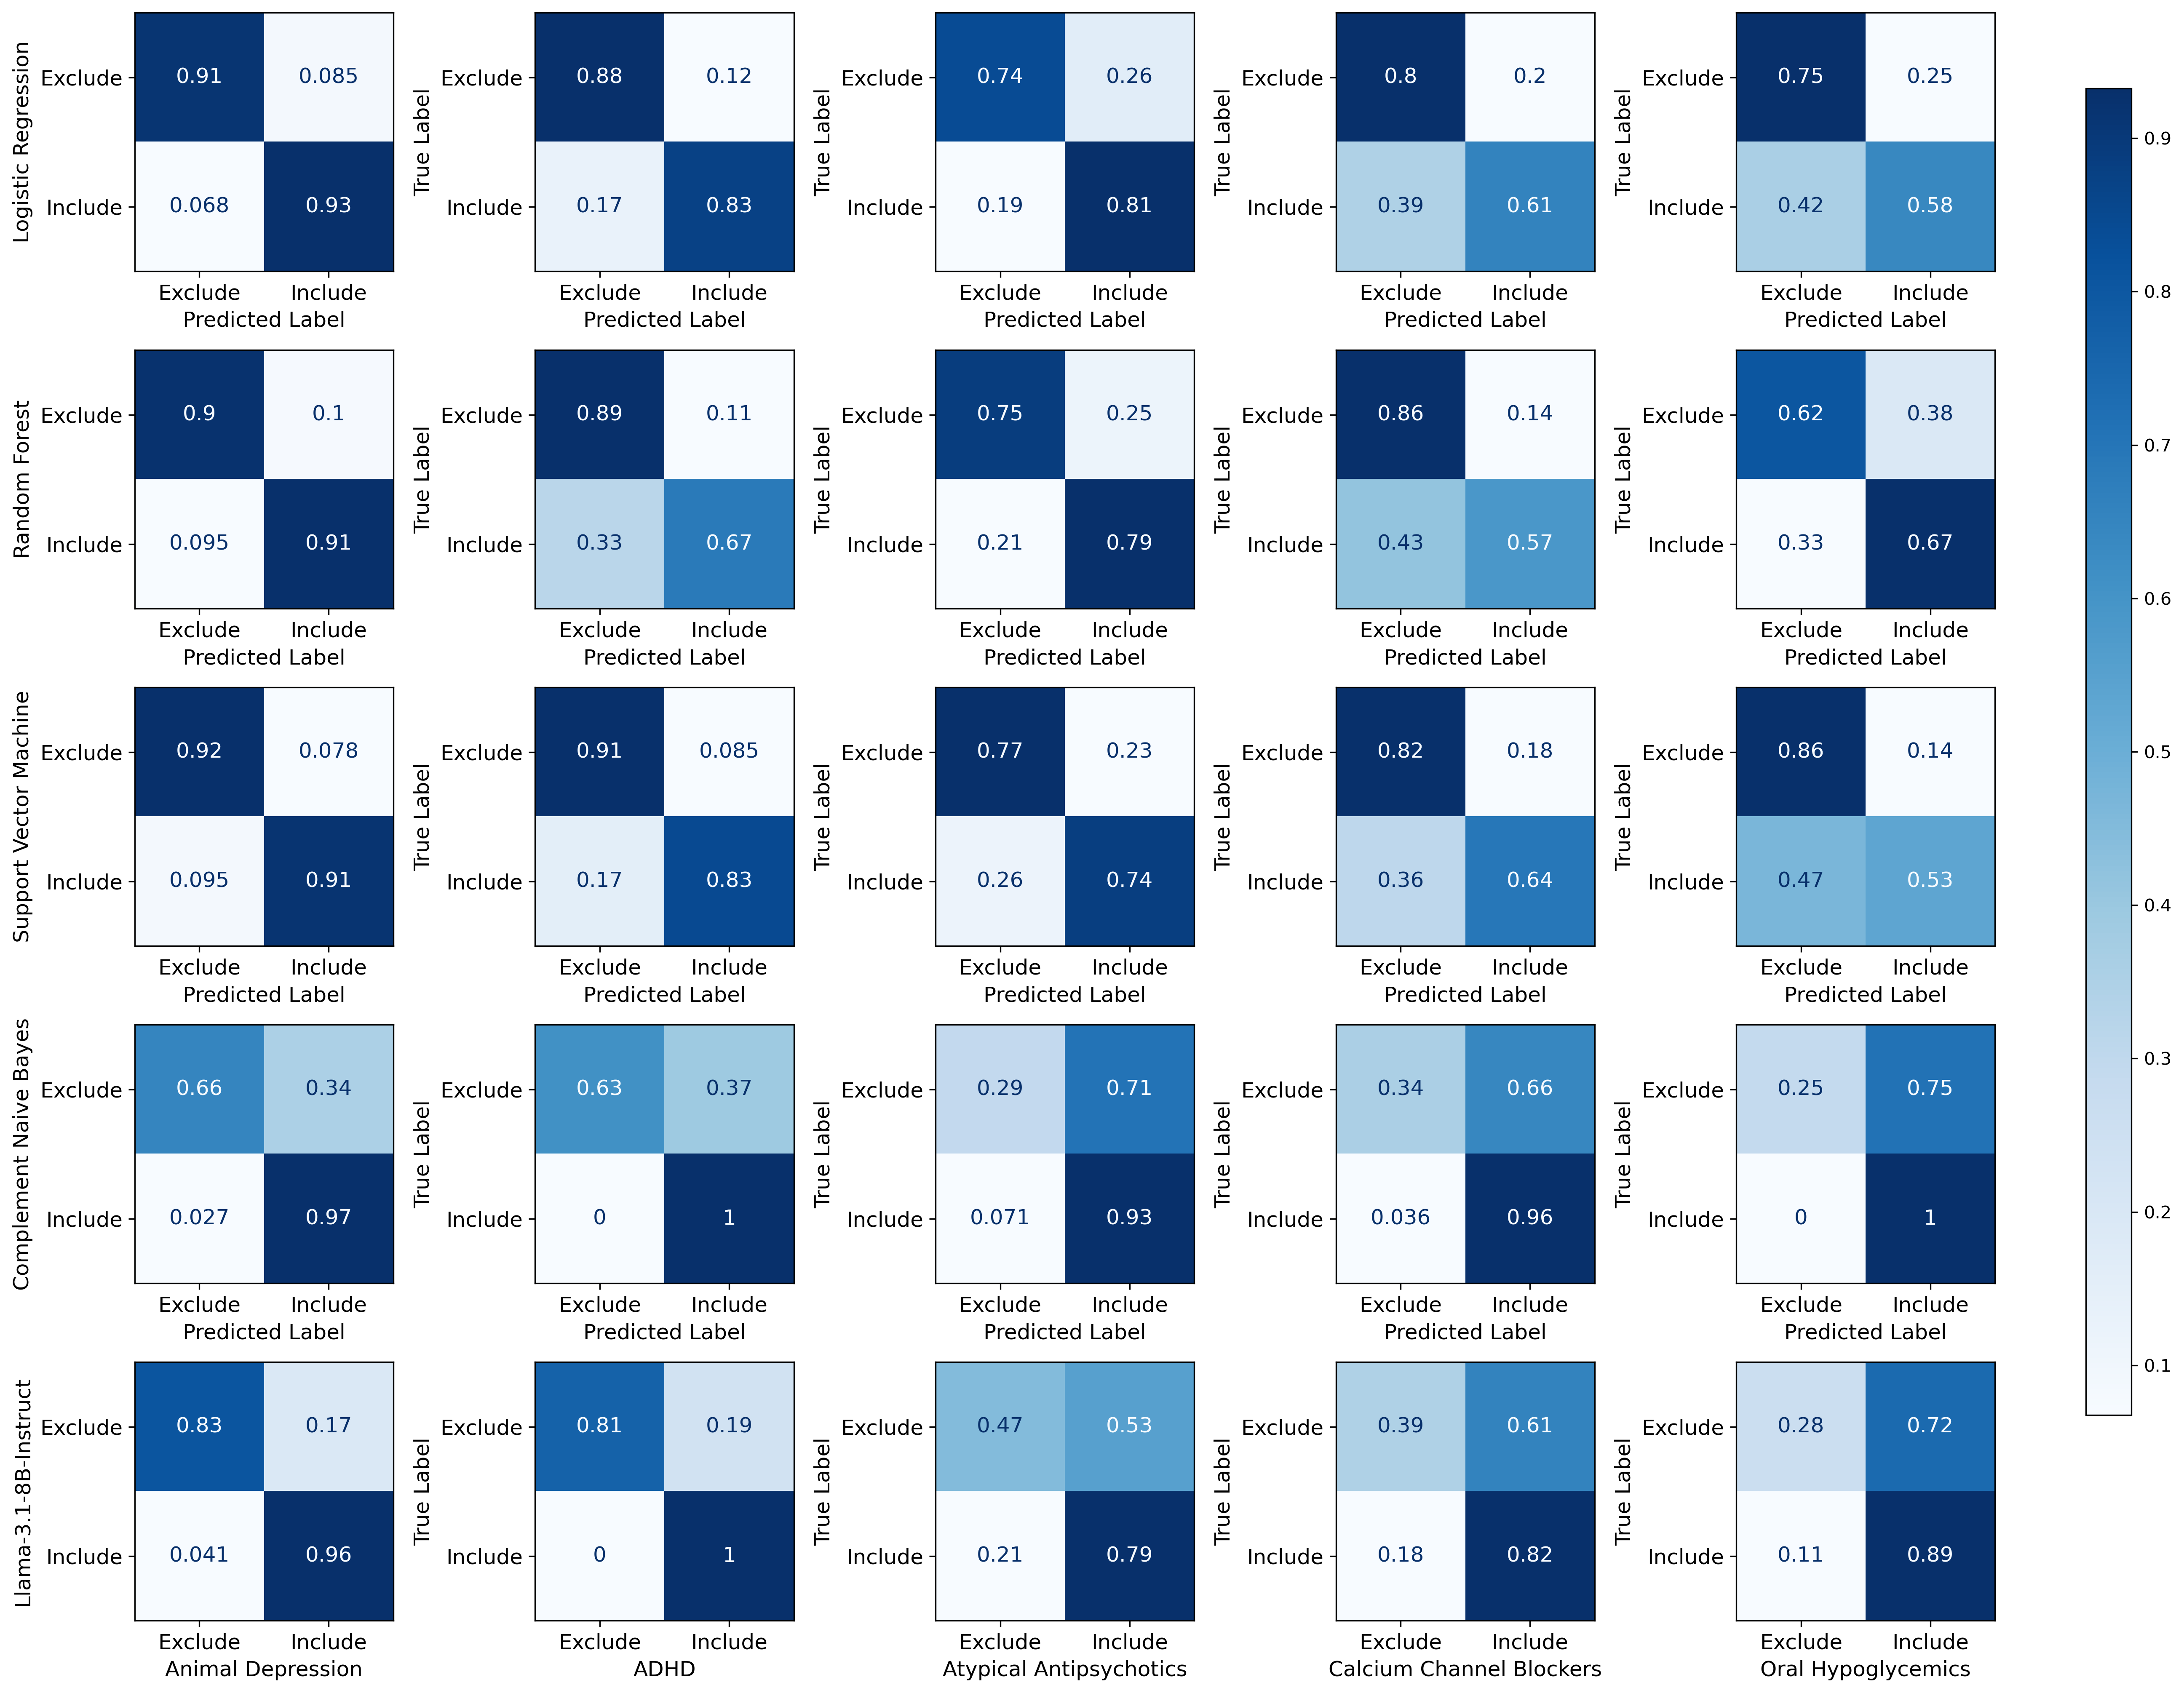

In [15]:
# Create a figure with subplots for each dataset and estimator
fig, axes = plt.subplots(len(estimators), len(datasets), figsize=(18, 15), dpi=300)  

# Iterate over each dataset and estimator to plot the confusion matrices
for i, estimator in enumerate(estimators):
    for j, dataset in enumerate(datasets):
        ax = axes[i, j]
        matrix_norm = results['datasets'][dataset][estimator]['matrix']['norm']
        plot_confusion_matrix(matrix_norm, ax, fontsize=12)

# Set the y-axis labels to the estimators
for i, estimator in enumerate(estimators):
    axes[i, 0].set_ylabel(estimator_dict[estimator], fontsize=12)

# Set the x-axis labels to the datasets below the lowest subplot in each column
for j, dataset in enumerate(datasets):
    axes[-1, j].set_xlabel(dataset_dict[dataset], fontsize=12)

# Add a single colorbar for all subplots
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
fig.colorbar(axes[0, 0].images[0], cax=cbar_ax)

plt.tight_layout(rect=[0, 0, 0.9, 0.90])

# Save the figure as an SVG file
plt.savefig('matrix_of_matrices.svg', format='svg')
plt.show()

### Per Dataset
Next, plot the confusion matrices for each dataset individually:

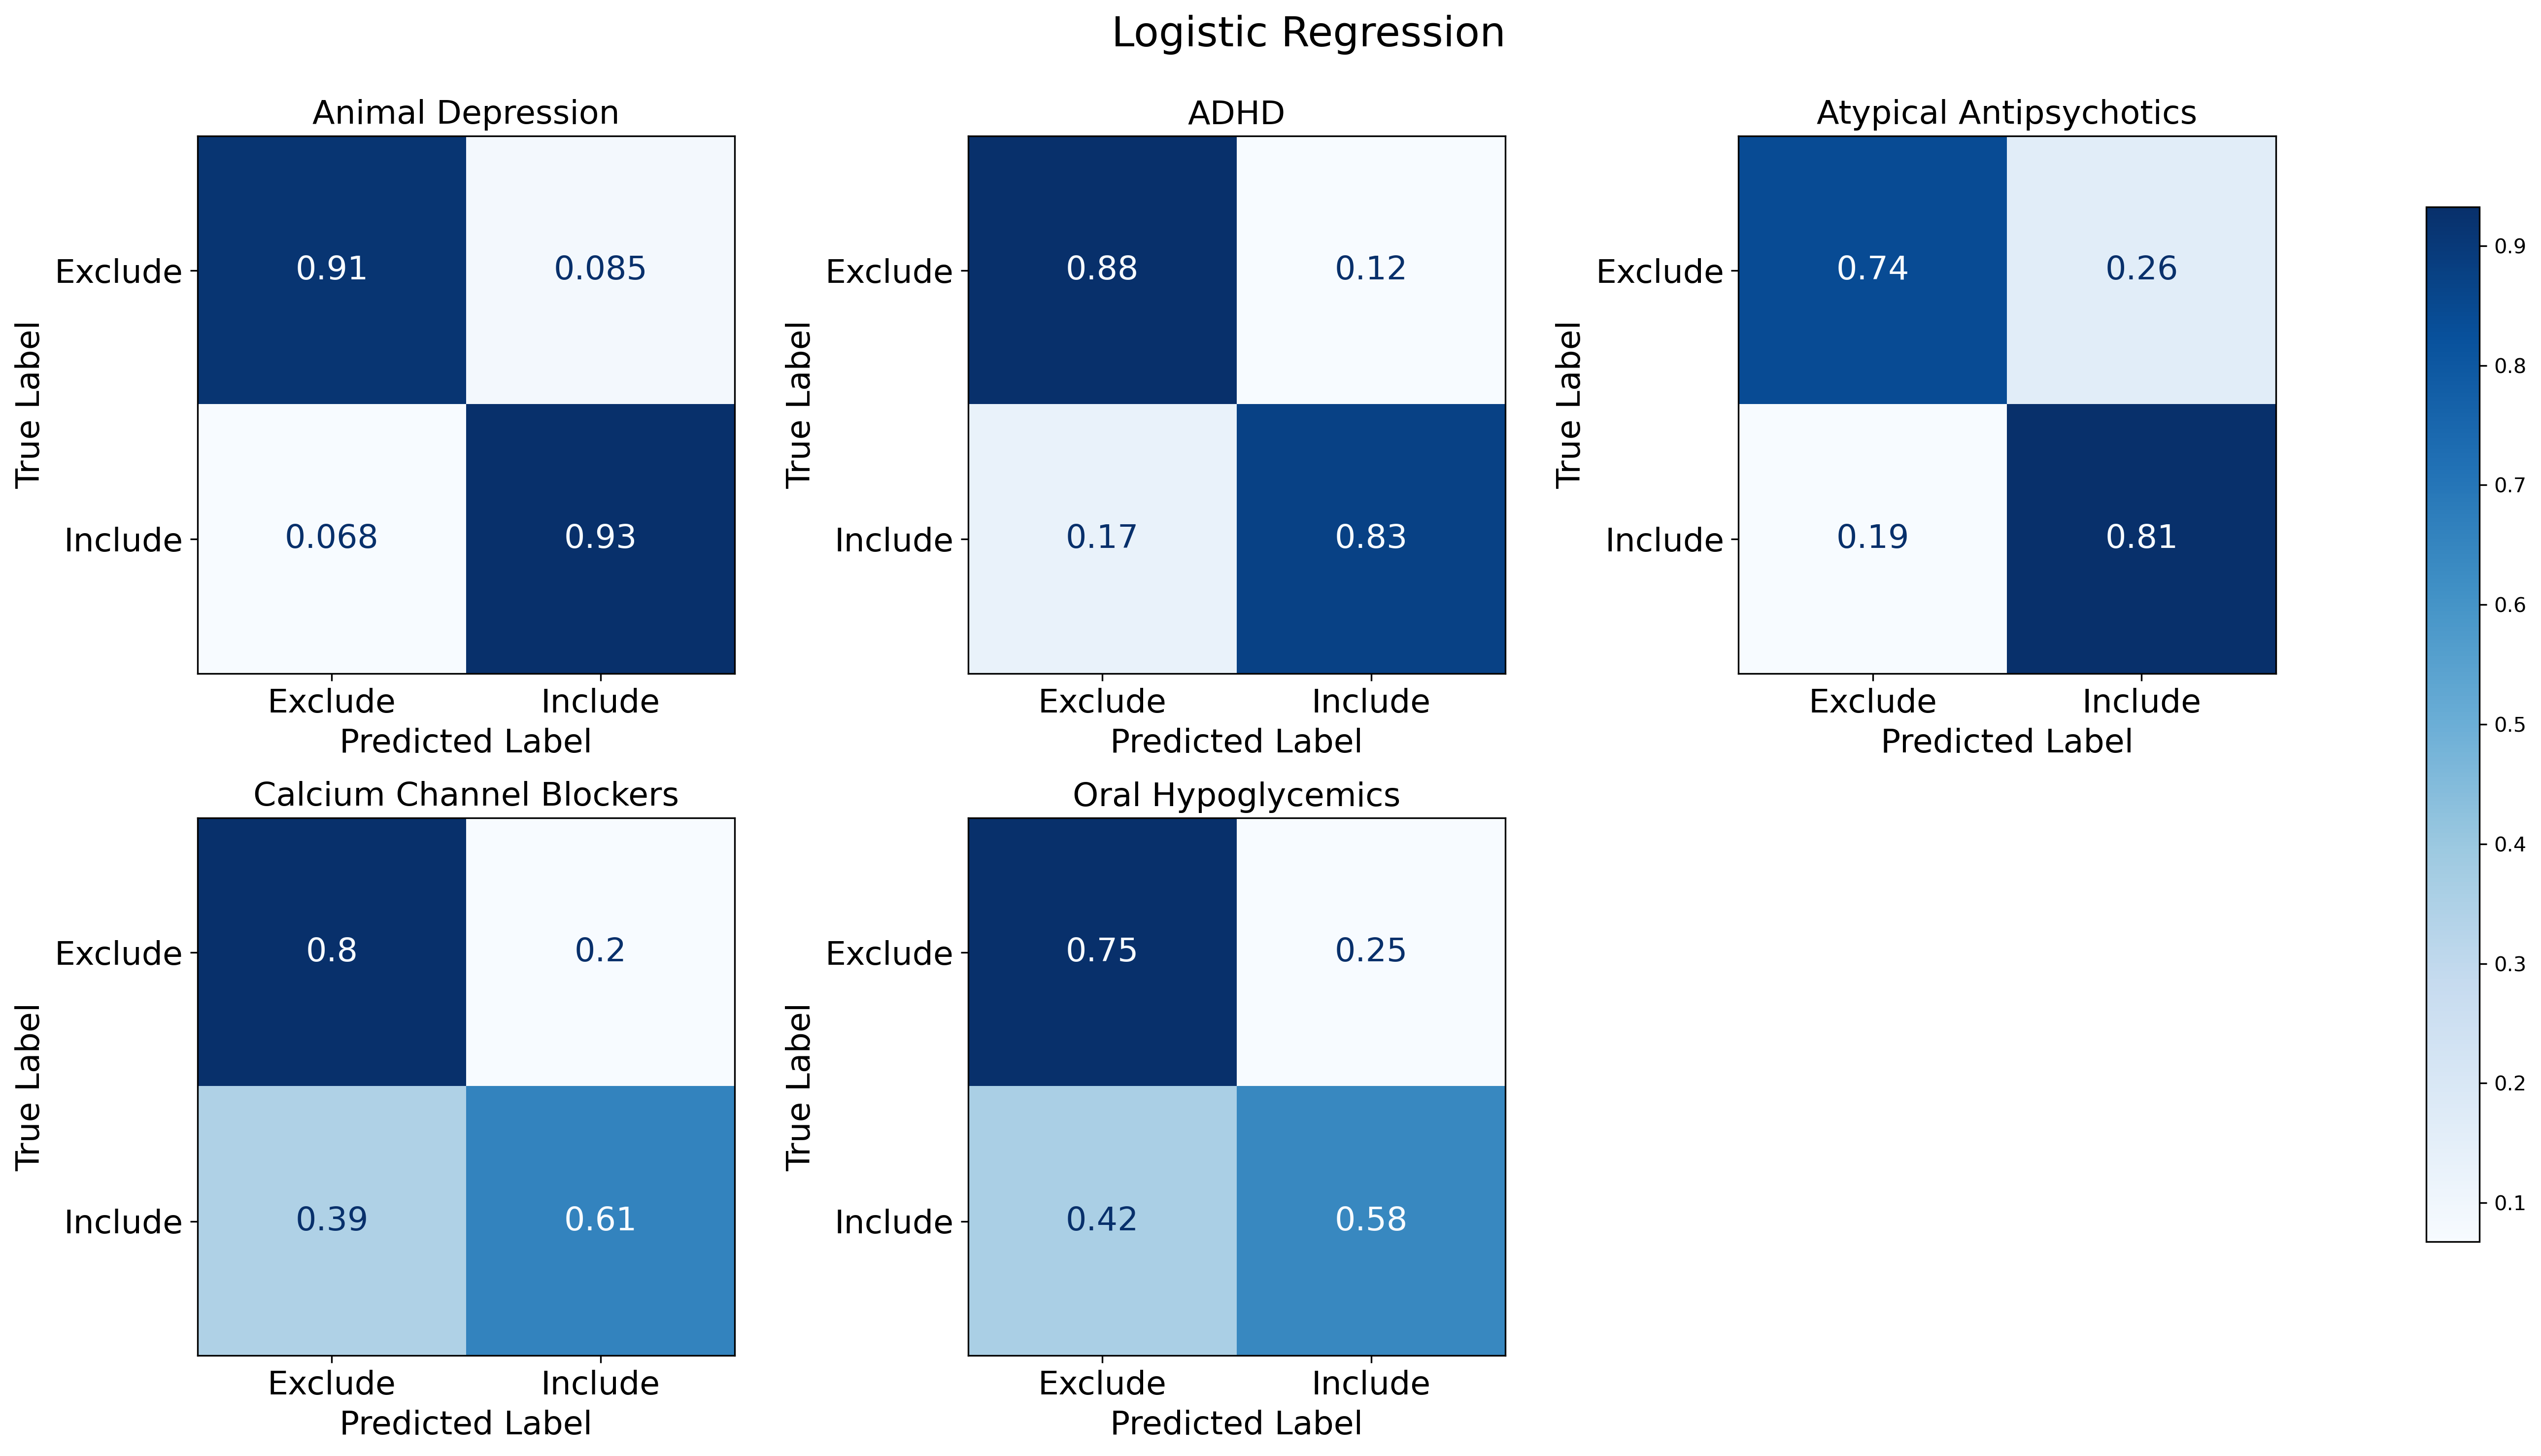

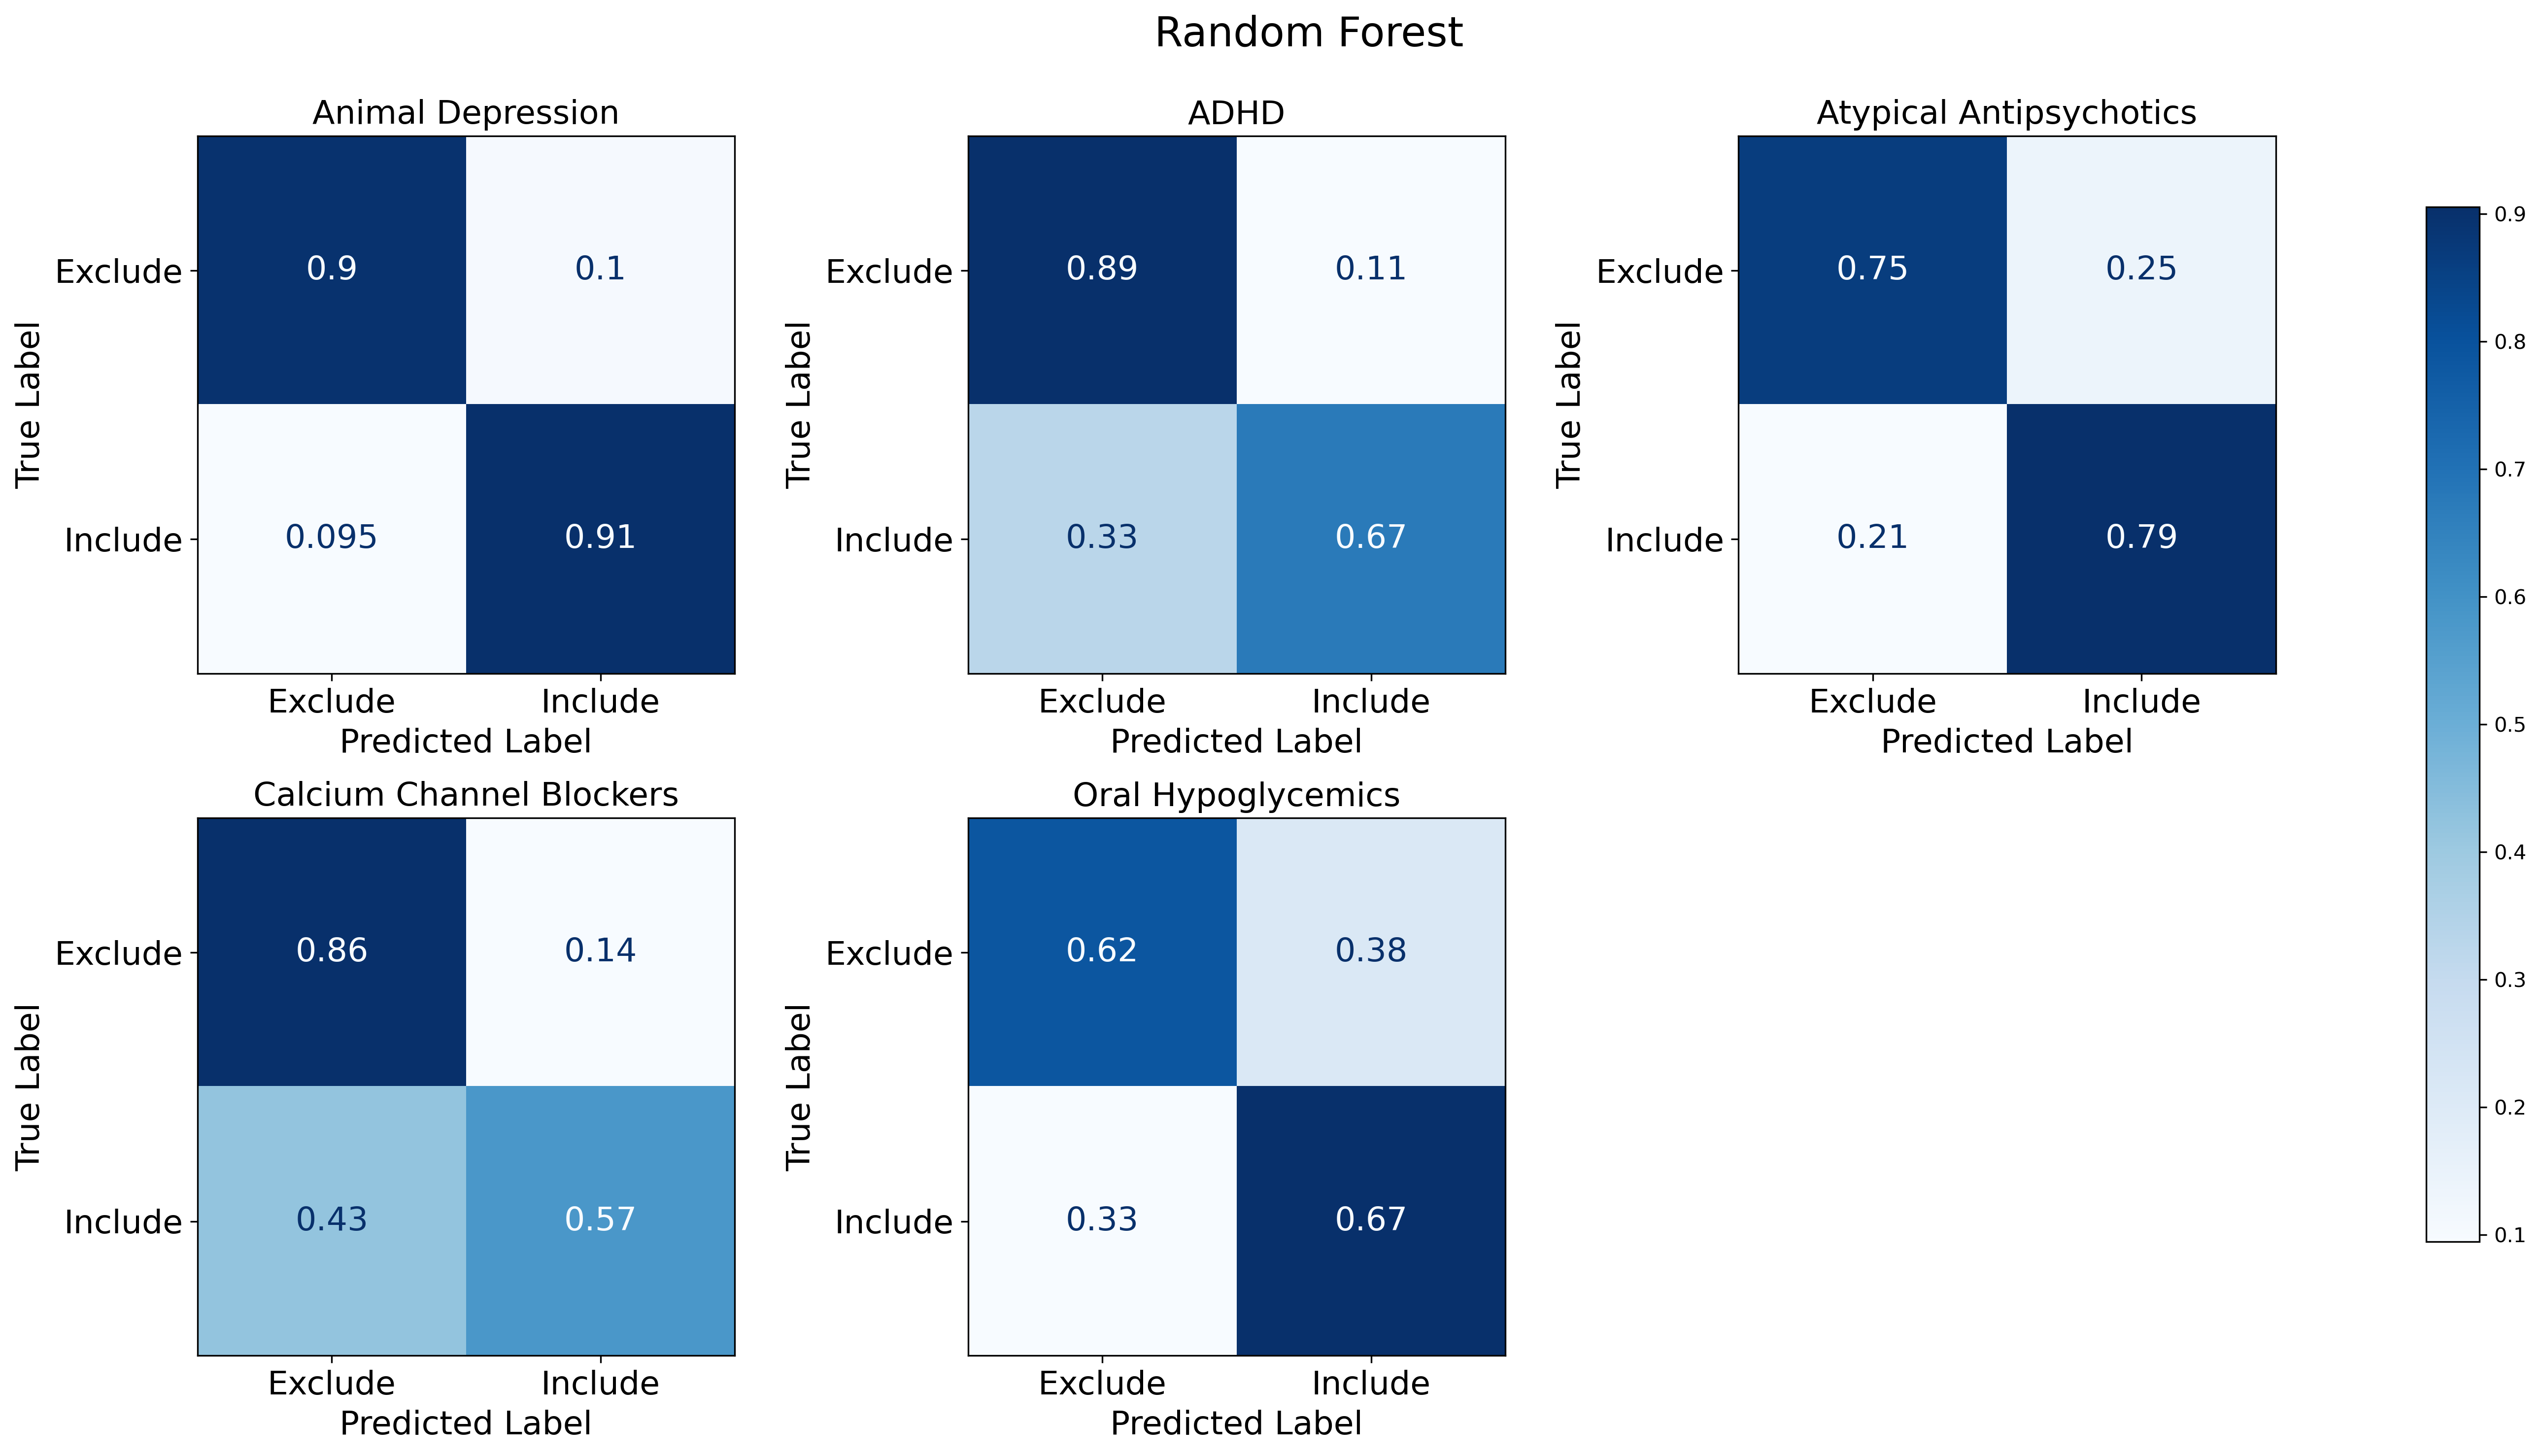

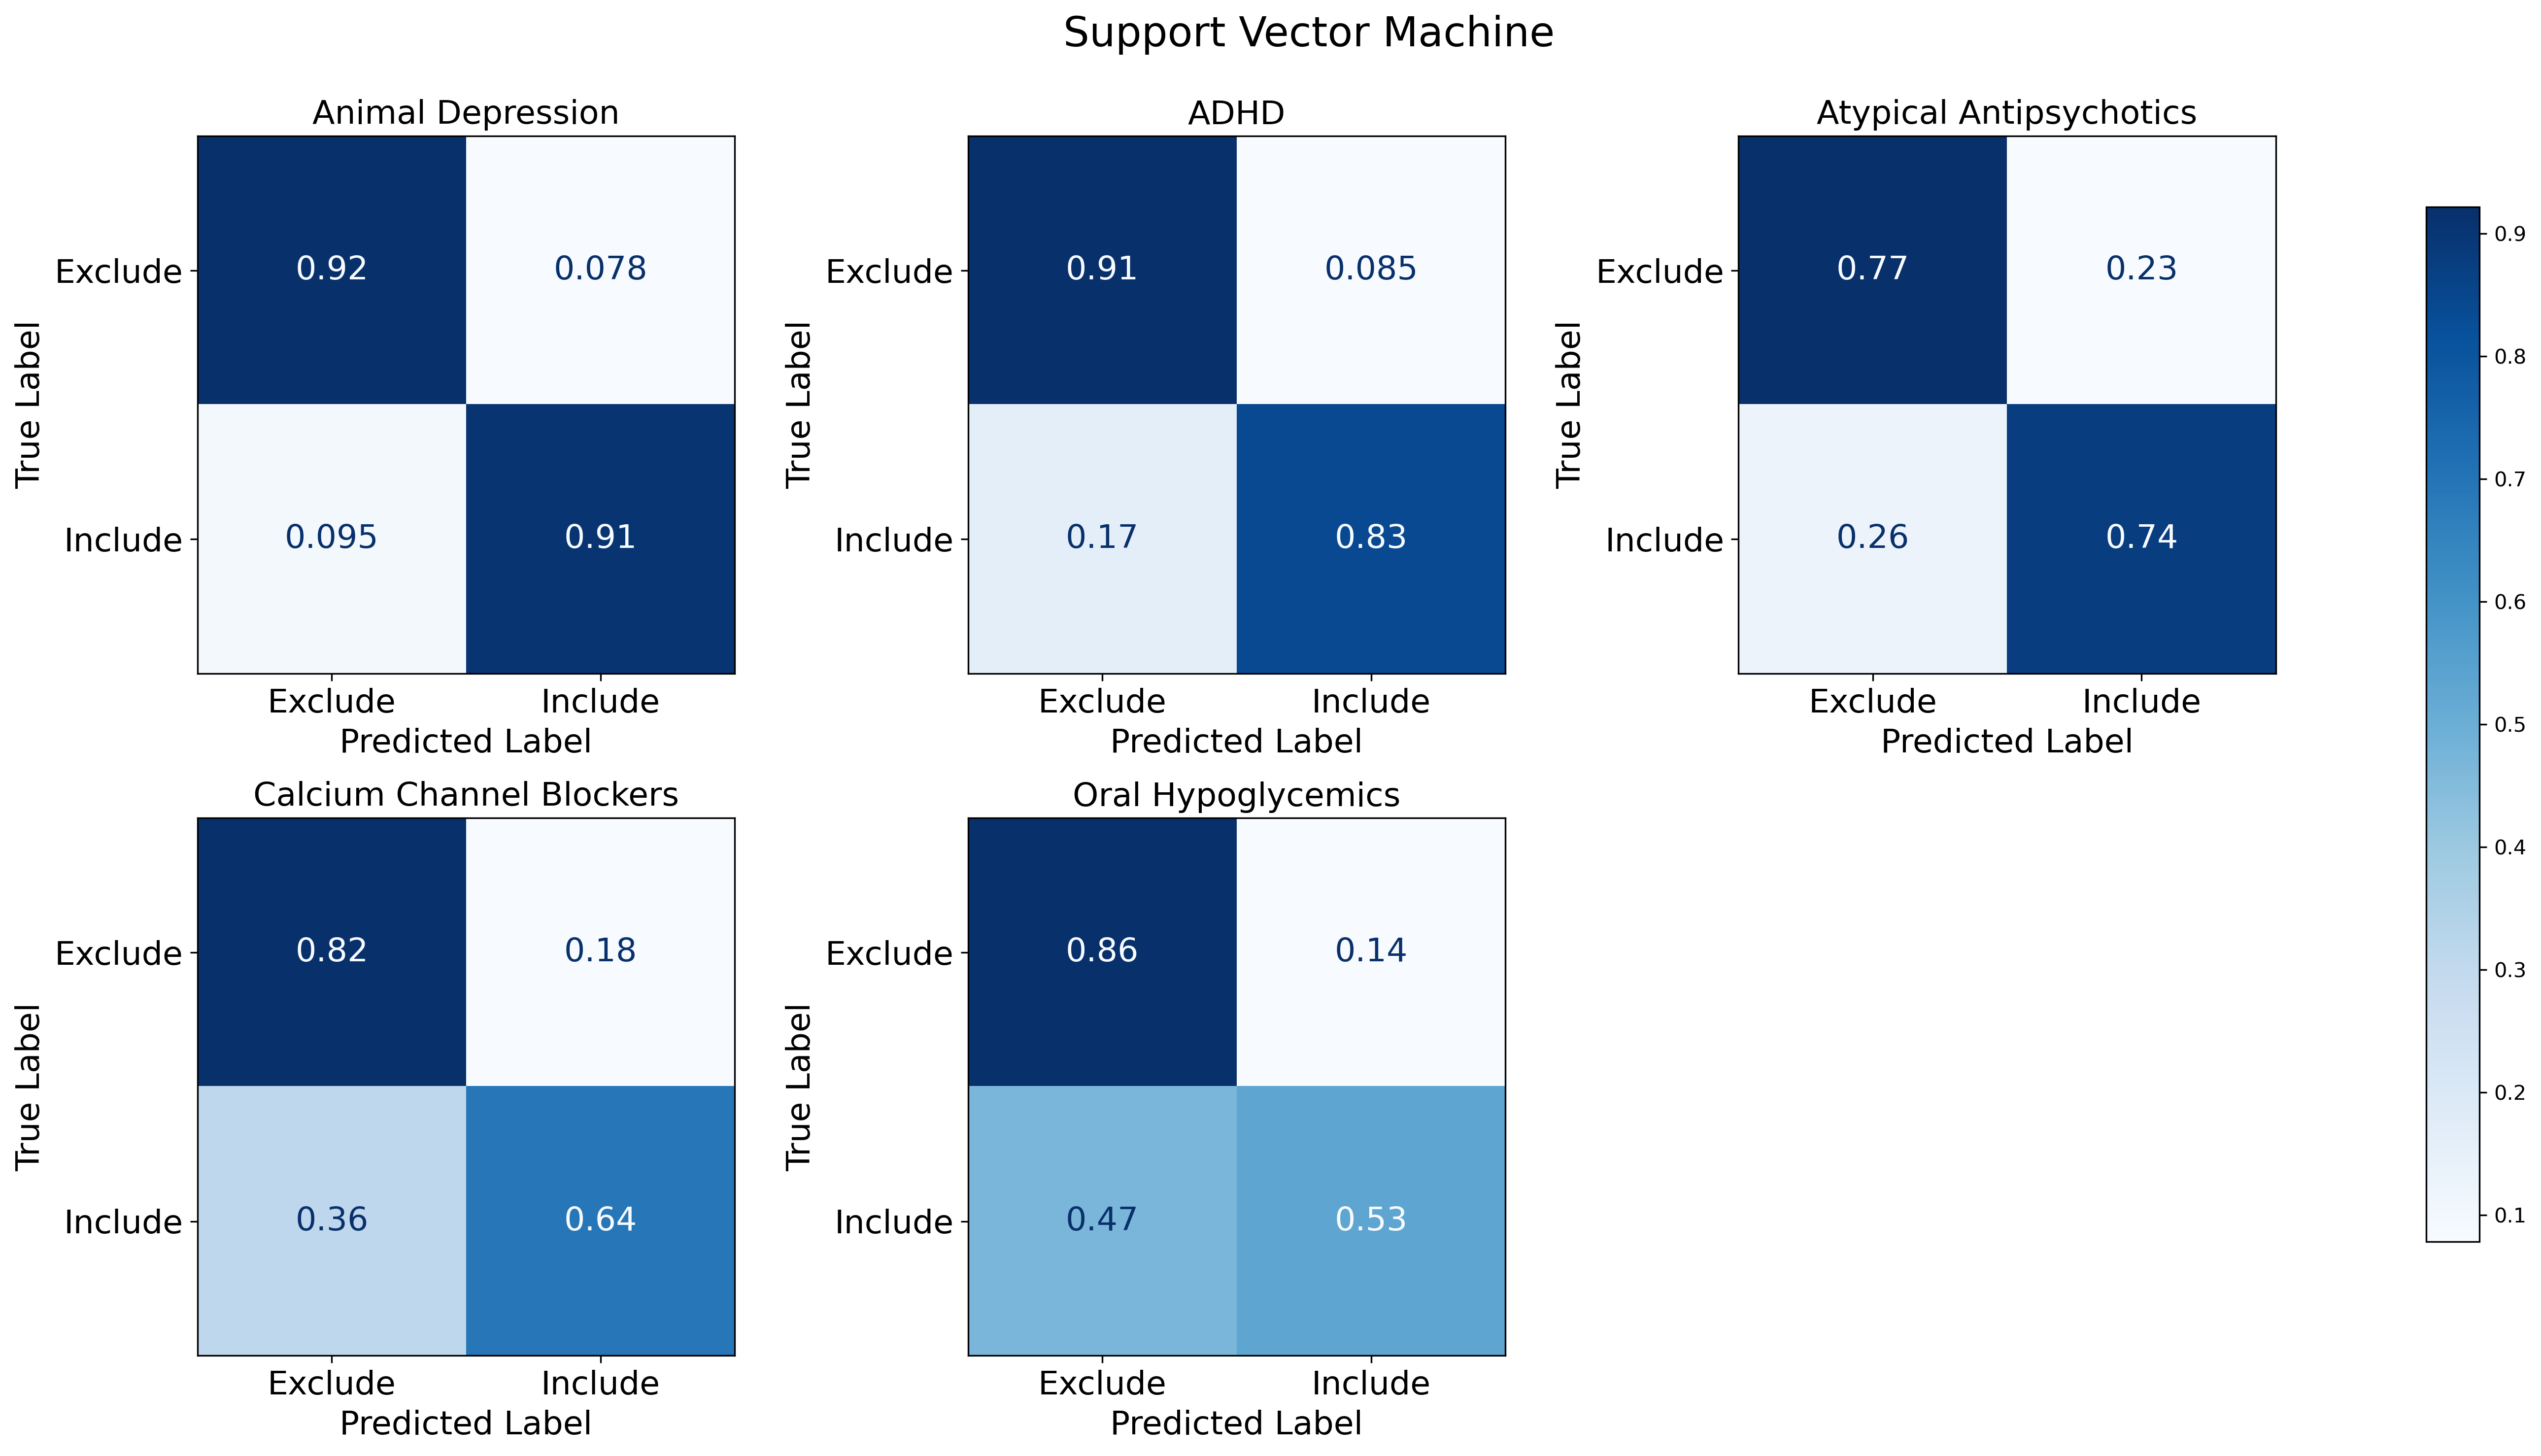

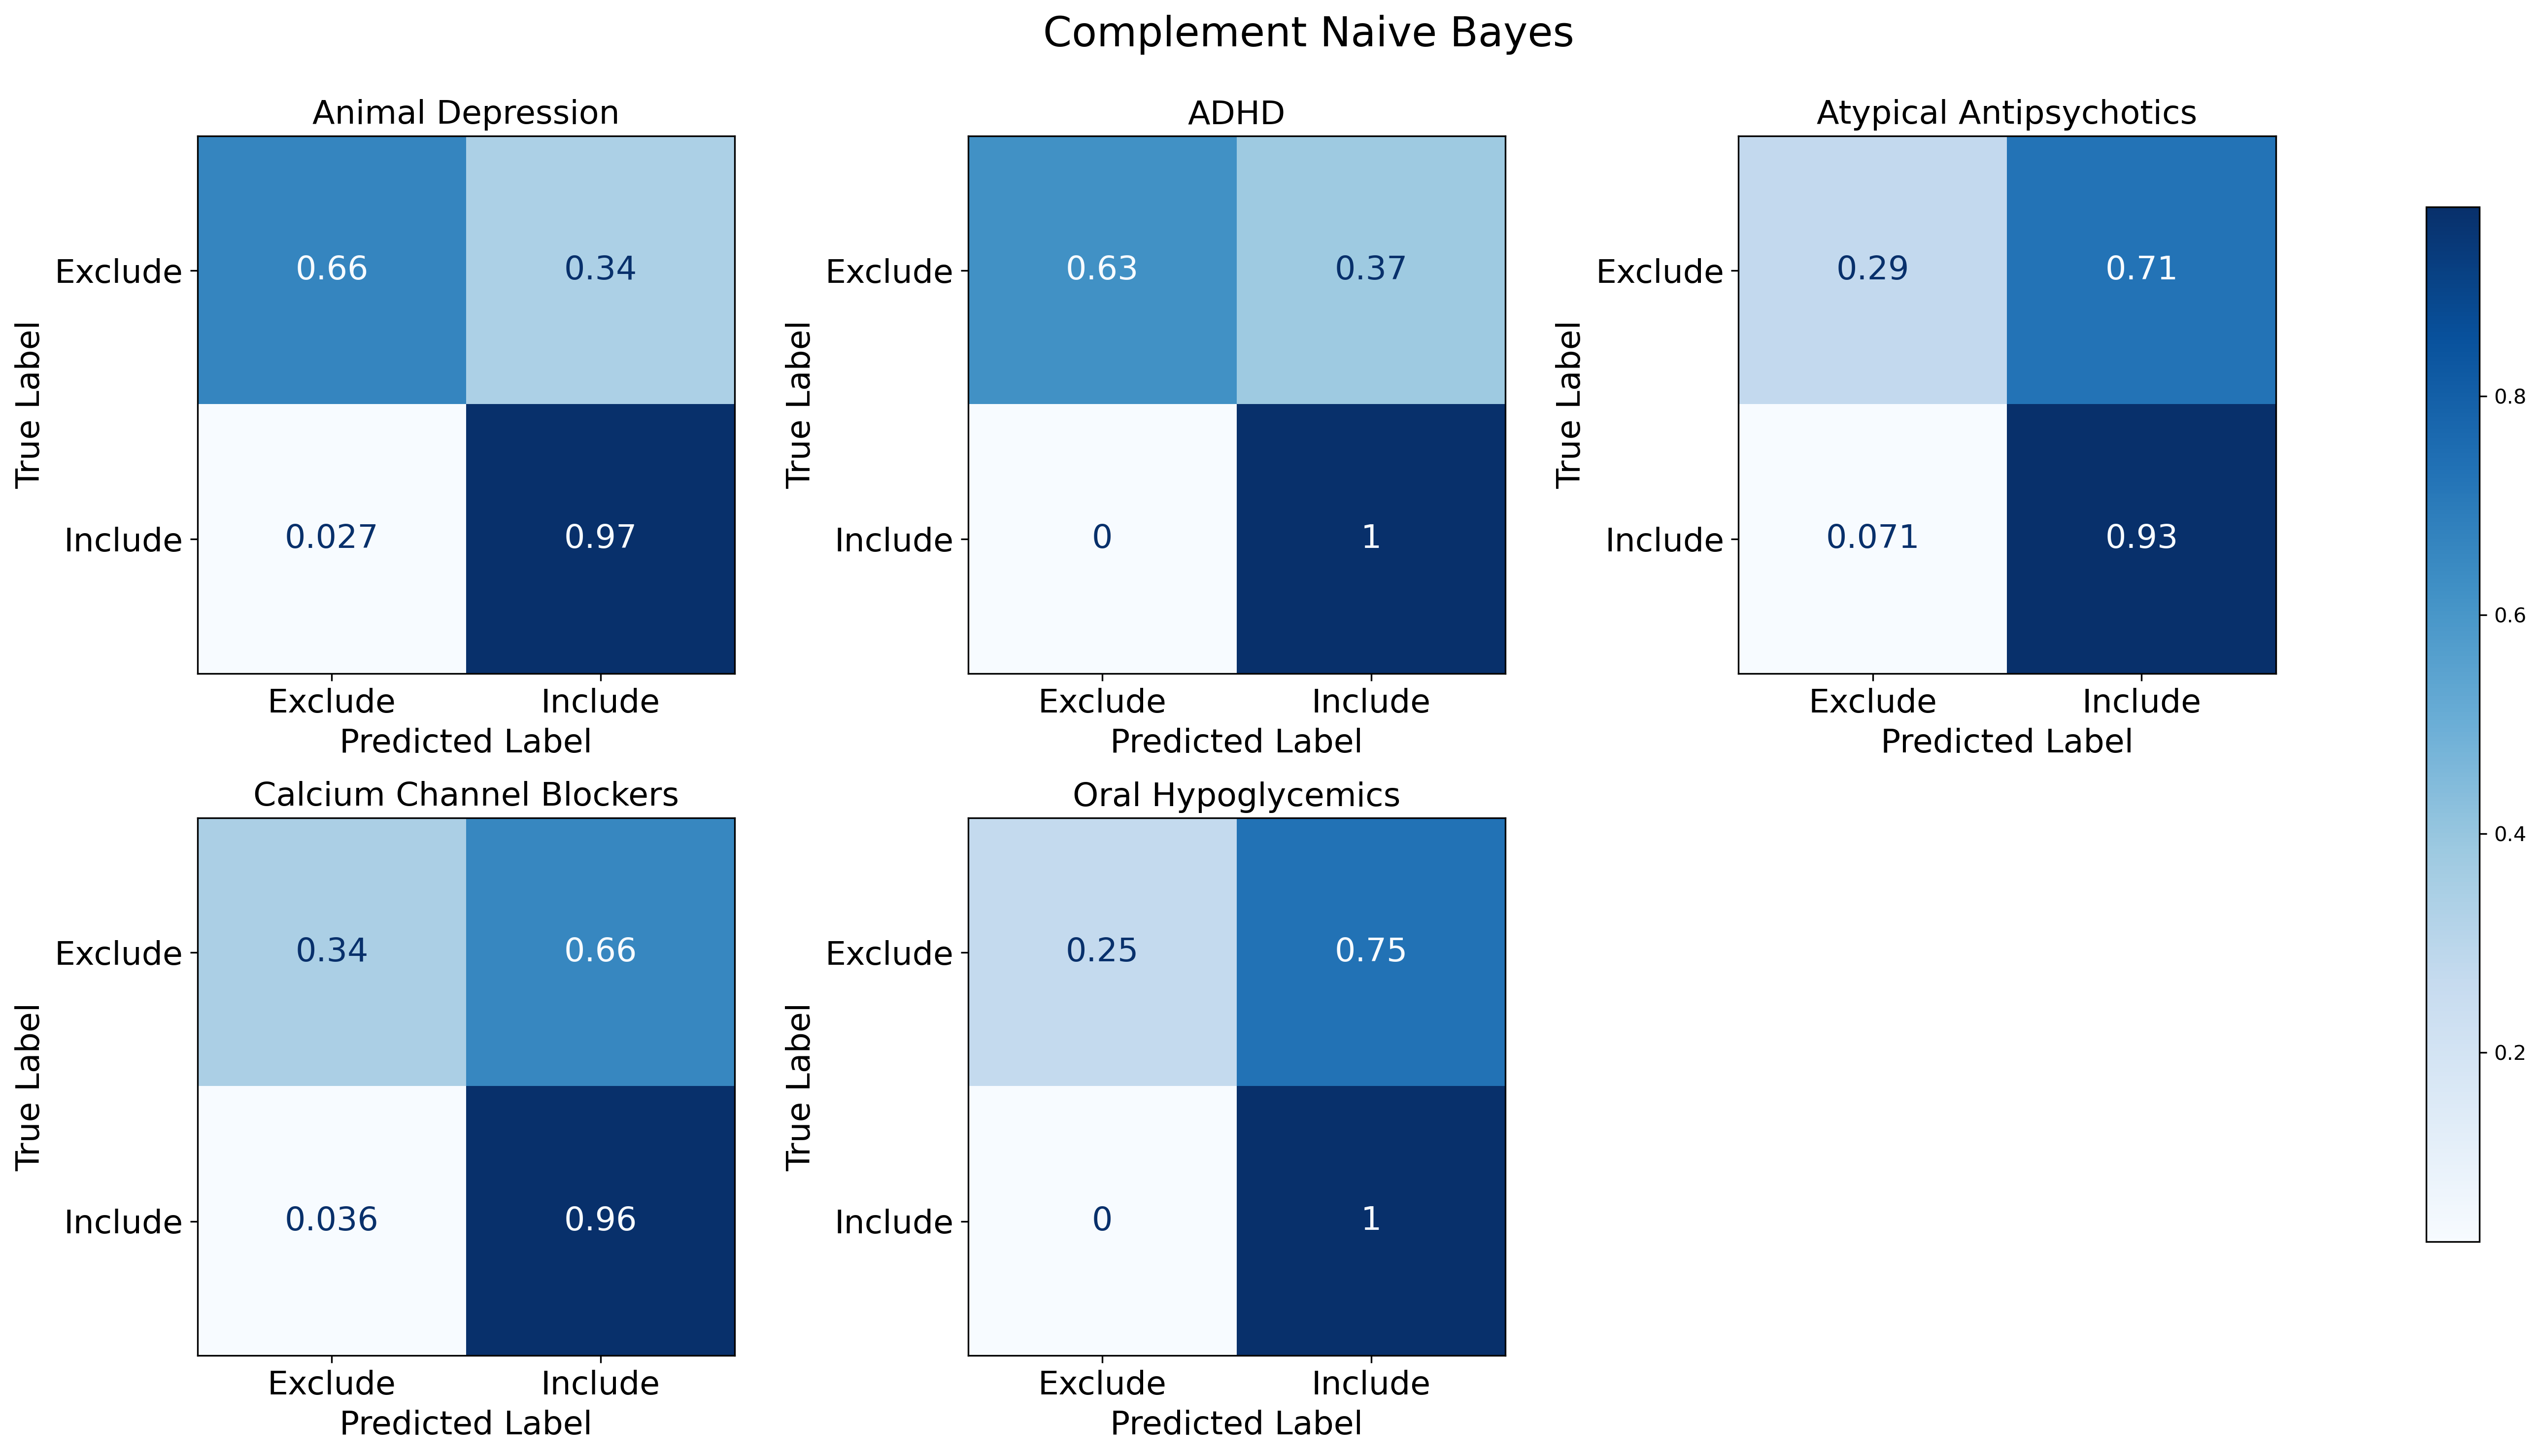

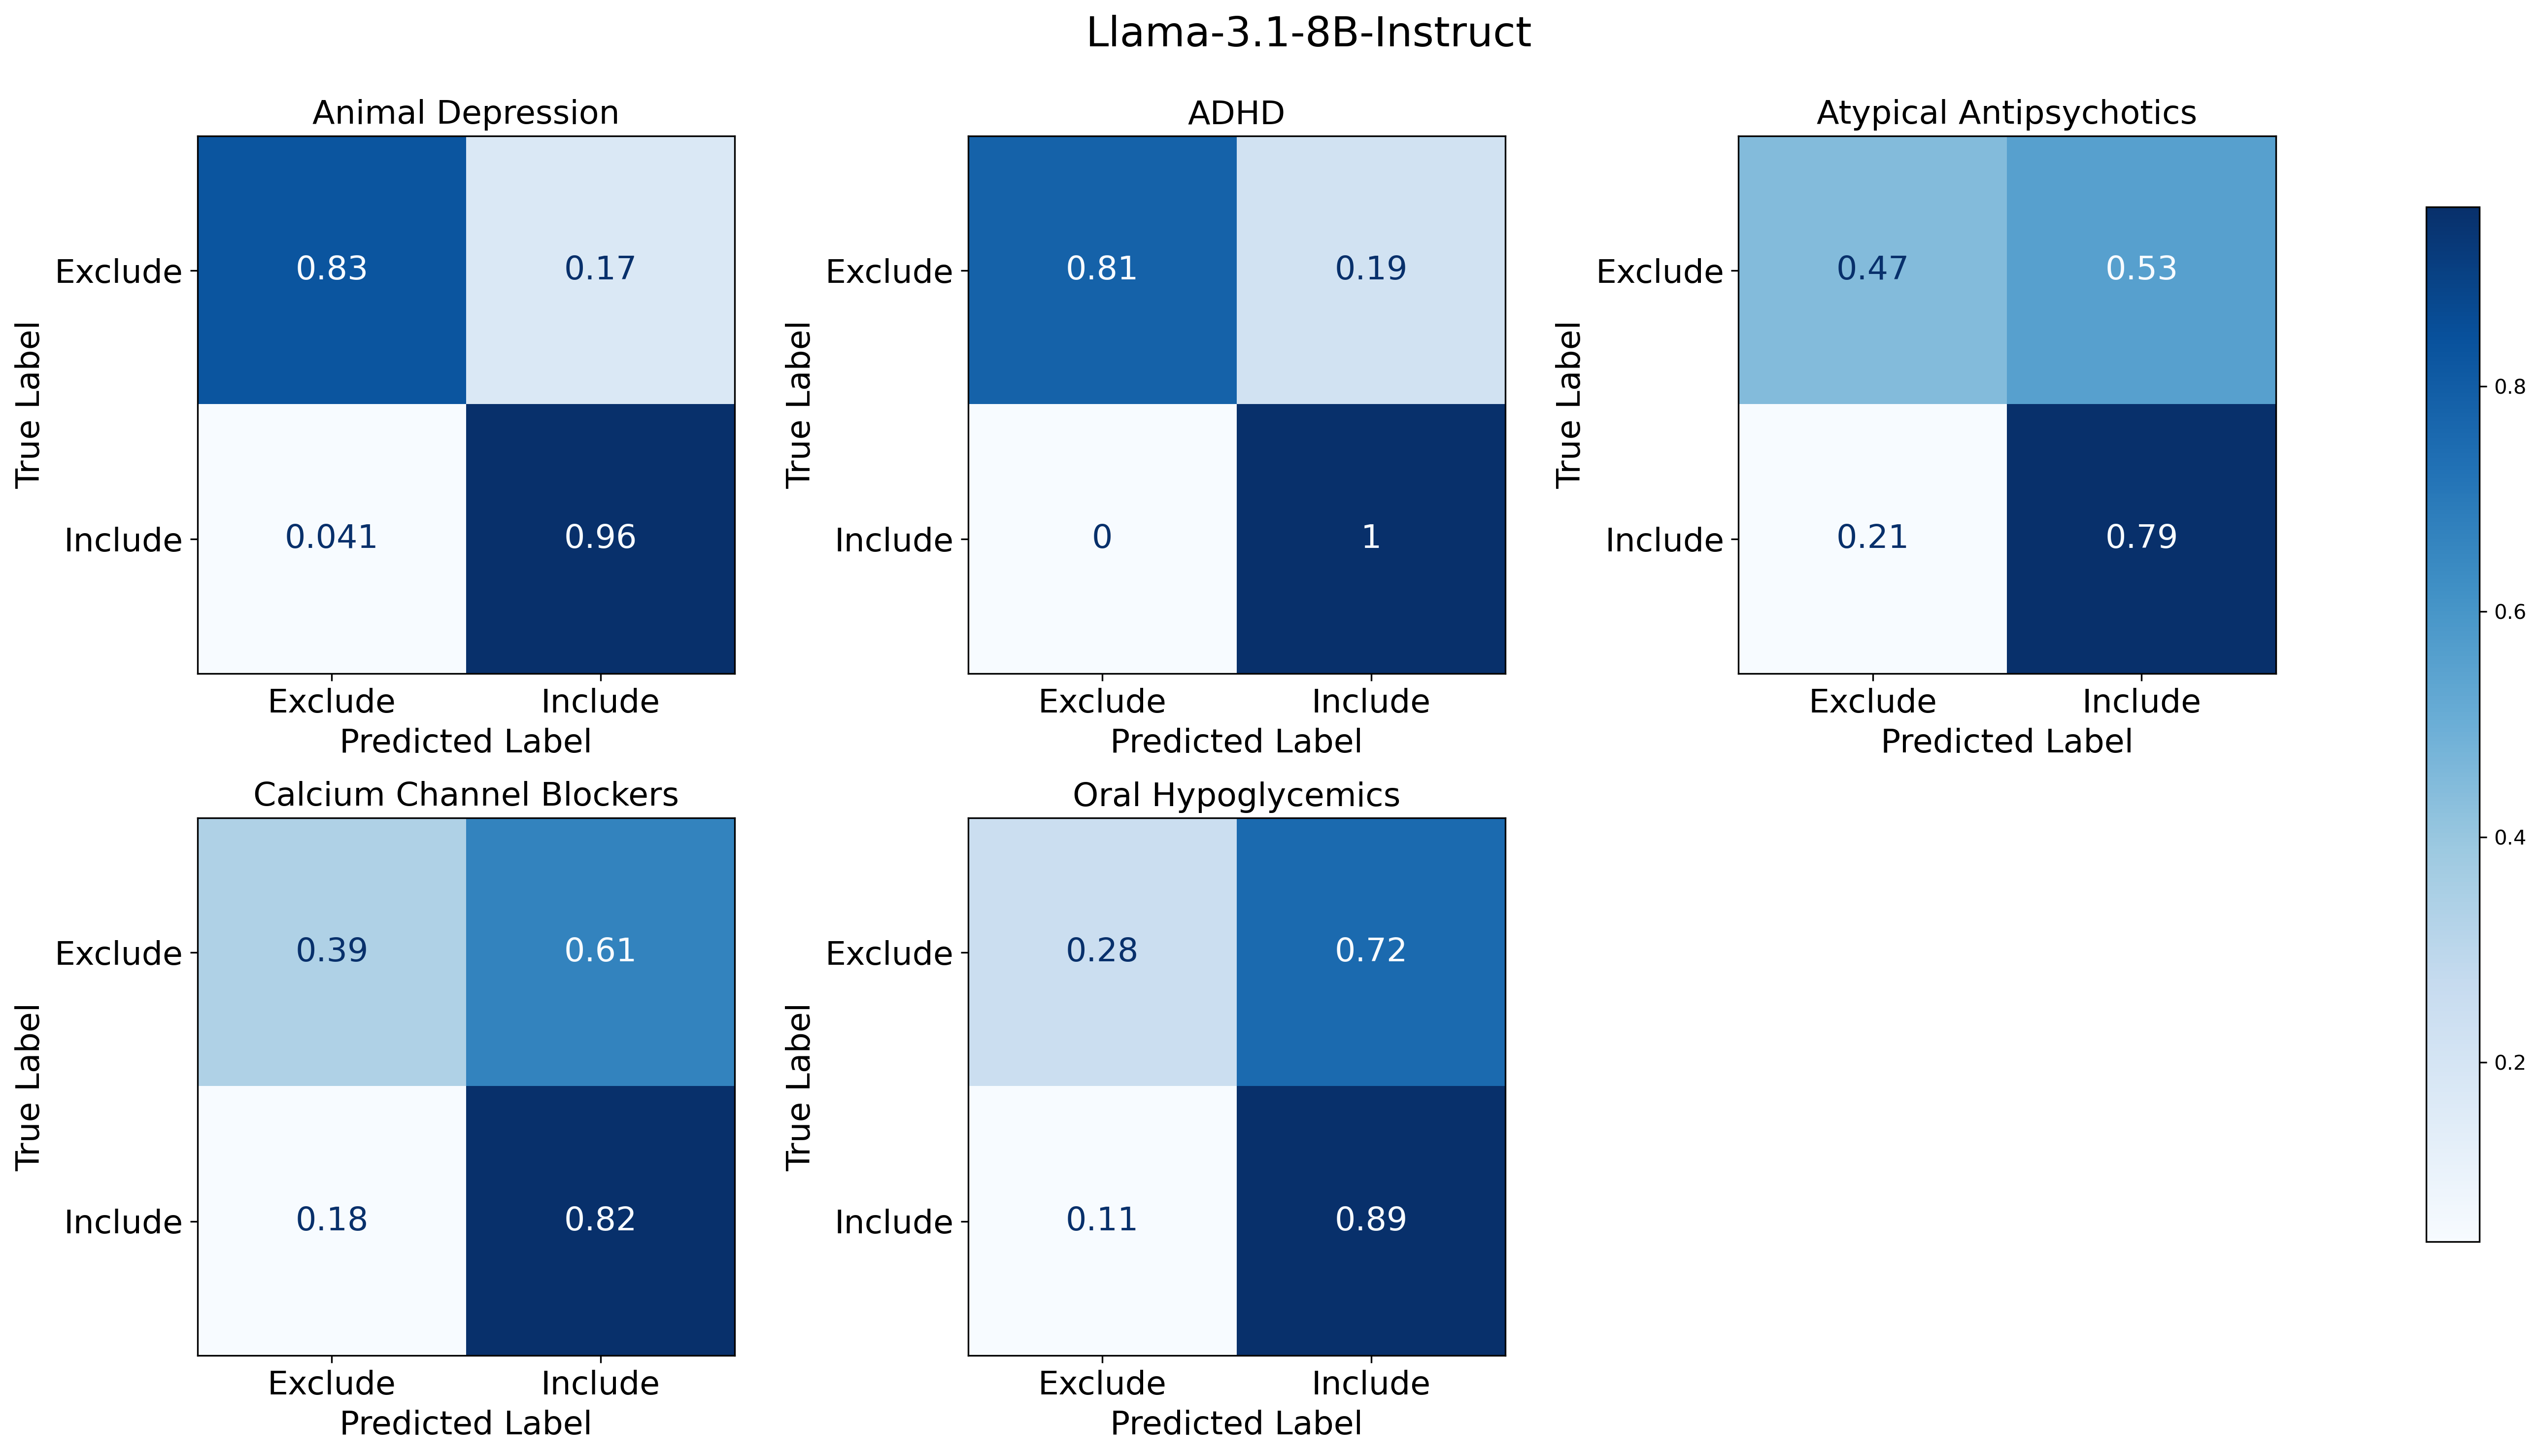

In [16]:
# Iterate over each estimator to create a separate figure
for estimator in estimators:
    fig, axes = plt.subplots(2, 3, figsize=(18, 10), dpi=300)  # Adjust the figure size as needed
    fig.suptitle(estimator_dict[estimator], fontsize=20)
    
    # Iterate over each dataset to plot the confusion matrices
    for j, dataset in enumerate(datasets):
        ax = axes[j // 3, j % 3]
        matrix_norm = results['datasets'][dataset][estimator]['matrix']['norm']
        plot_confusion_matrix(matrix_norm, ax, fontsize=16)
        ax.set_title(dataset_dict[dataset], fontsize=16)
    
    # Add a single colorbar for all subplots
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    fig.colorbar(axes[0, 0].images[0], cax=cbar_ax)
    
    plt.tight_layout(rect=[0, 0, 0.9, 0.98])

    axes[1,2].set_visible(False)  # Hide the empty subplot where the pancreatic surgery confusion matrix would be
    
    # Save the figure as an SVG file
    plt.savefig(f'confusion_matrices_{estimator}.svg', format='svg')
    plt.show()

# Bootstrap Samples

### Average Recall and Specificity
Using the scores we can visually inspect the average recall and specificity across all datasets and put them into perspective with human benchmarks known through the literature:

In [17]:
# Human benchmark values from Gartlehner et al. (2020)
human_recall = 0.865
human_specificity = 0.79

In [18]:
# values for different colors
marine_blue = '#004a71'
light_blue = '#009ee0'
orange='#EC963E'
cyan = '#34B2A6'
grey = '#797B7F'

# color set for boxplots
colors = {
    'boxes': marine_blue,
    'whiskers': cyan,
    'medians': orange,
    'caps': grey
}

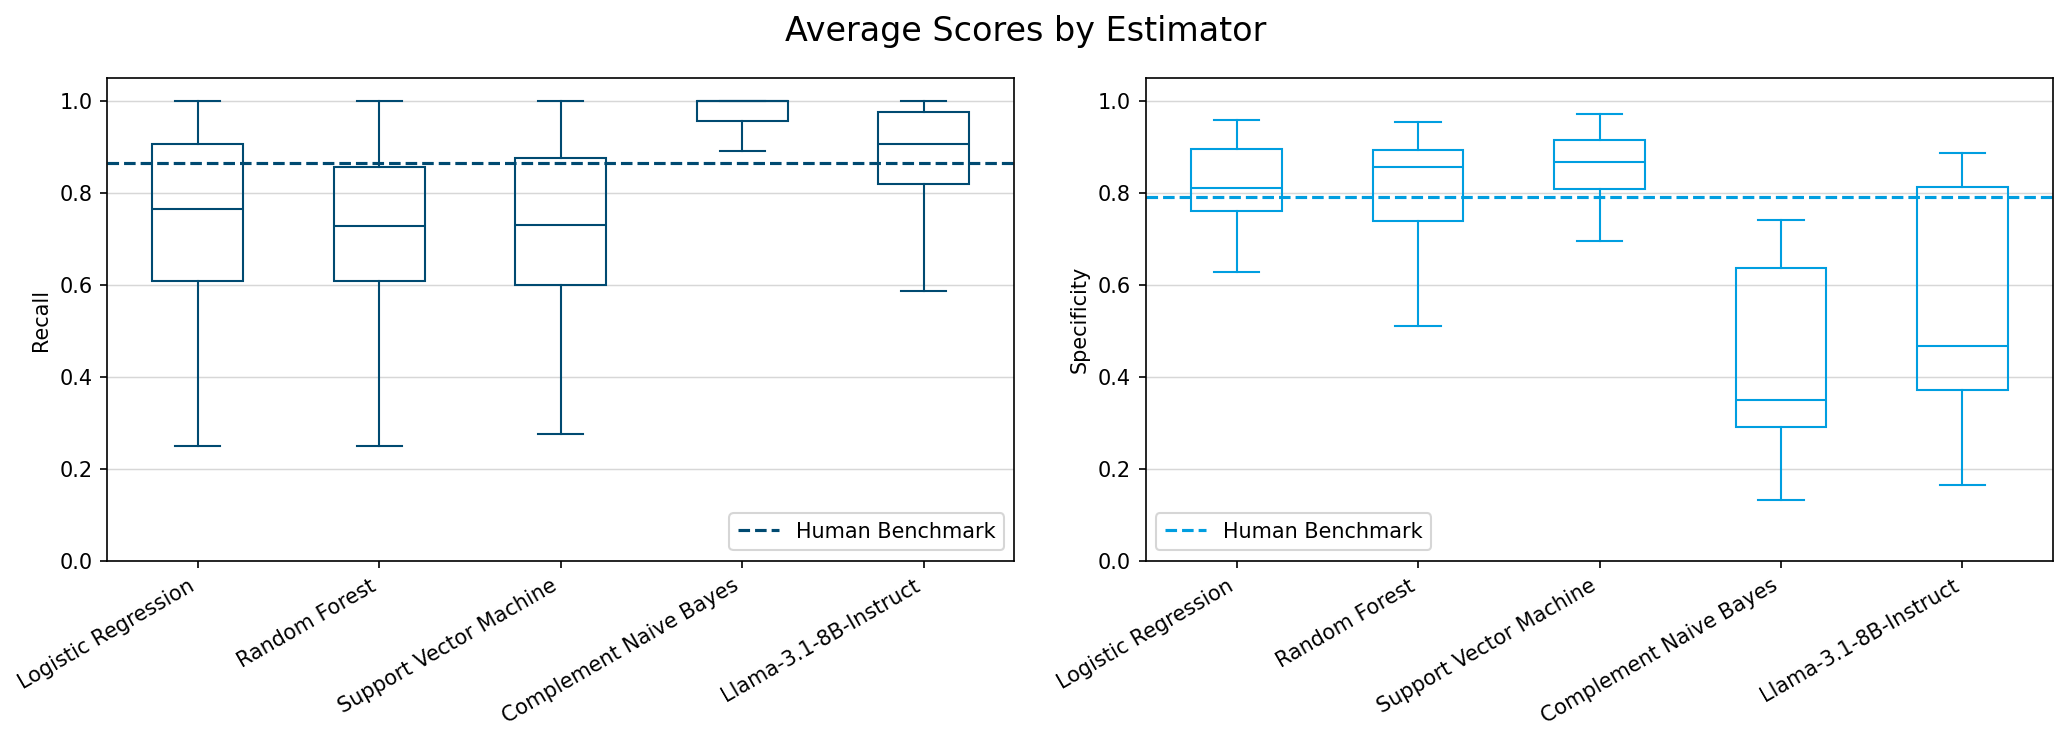

In [19]:
import numpy as np

# Gather all recall and specificity bootstrap scores across datasets per estimator
recall_scores = []
specificity_scores = []
for est in estimators:
    recall_all = []
    specificity_all = []
    for dataset in results['datasets']:
        recall_all.extend(results['datasets'][dataset][est]['bootstrap']['scores']['recall'])
        specificity_all.extend(results['datasets'][dataset][est]['bootstrap']['scores']['specificity'])
    recall_scores.append(recall_all)
    specificity_scores.append(specificity_all)


fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=150)

# Recall boxplot
axes[0].boxplot(
    recall_scores,
    patch_artist=True,
    boxprops=dict(facecolor='none', edgecolor=marine_blue, linewidth=1),
    medianprops=dict(color=marine_blue, linewidth=1),
    whiskerprops=dict(color=marine_blue, linewidth=1),
    capprops=dict(color=marine_blue, linewidth=1),
    showfliers=False, # set to True to print outliers
    # uncomment to format outliers in blue
    #flierprops=dict(markerfacecolor='none', markeredgecolor=marine_blue)
)
axes[0].axhline(human_recall, color=marine_blue, linestyle='--', linewidth=1.5, label='Human Benchmark')
axes[0].set_ylabel('Recall')
axes[0].set_xticks(np.arange(1, len(estimator_labels)+1))
axes[0].set_xticklabels(estimator_labels, rotation=30, ha='right')
axes[0].set_ylim(0, 1.05)
axes[0].legend(loc='lower right')
axes[0].grid(True, axis='y', linestyle='-', linewidth=0.7, alpha=0.5)

# Specificity boxplot
axes[1].boxplot(
    specificity_scores,
    patch_artist=True,
    boxprops=dict(facecolor='none', edgecolor=light_blue, linewidth=1),
    medianprops=dict(color=light_blue, linewidth=1),
    whiskerprops=dict(color=light_blue, linewidth=1),
    capprops=dict(color=light_blue, linewidth=1),
    showfliers=False, # set to True to print outliers
    # uncomment to format outliers in blue
    #flierprops=dict(markerfacecolor='none', markeredgecolor=light_blue)
)
axes[1].axhline(human_specificity, color=light_blue, linestyle='--', linewidth=1.5, label='Human Benchmark')
axes[1].set_ylabel('Specificity')
axes[1].set_xticks(np.arange(1, len(estimator_labels)+1))
axes[1].set_xticklabels(estimator_labels, rotation=30, ha='right')
axes[1].set_ylim(0, 1.05)
axes[1].legend(loc='lower left')
axes[1].grid(True, axis='y', linestyle='-', linewidth=0.7, alpha=0.5)

fig.suptitle('Average Scores by Estimator', fontsize=16)
plt.tight_layout()
plt.savefig('average scores by estimator.svg', format='svg')
plt.show()

### Recall and Specificity per Dataset
We can further zoom in to inspect recall and specificity for one dataset at a time:

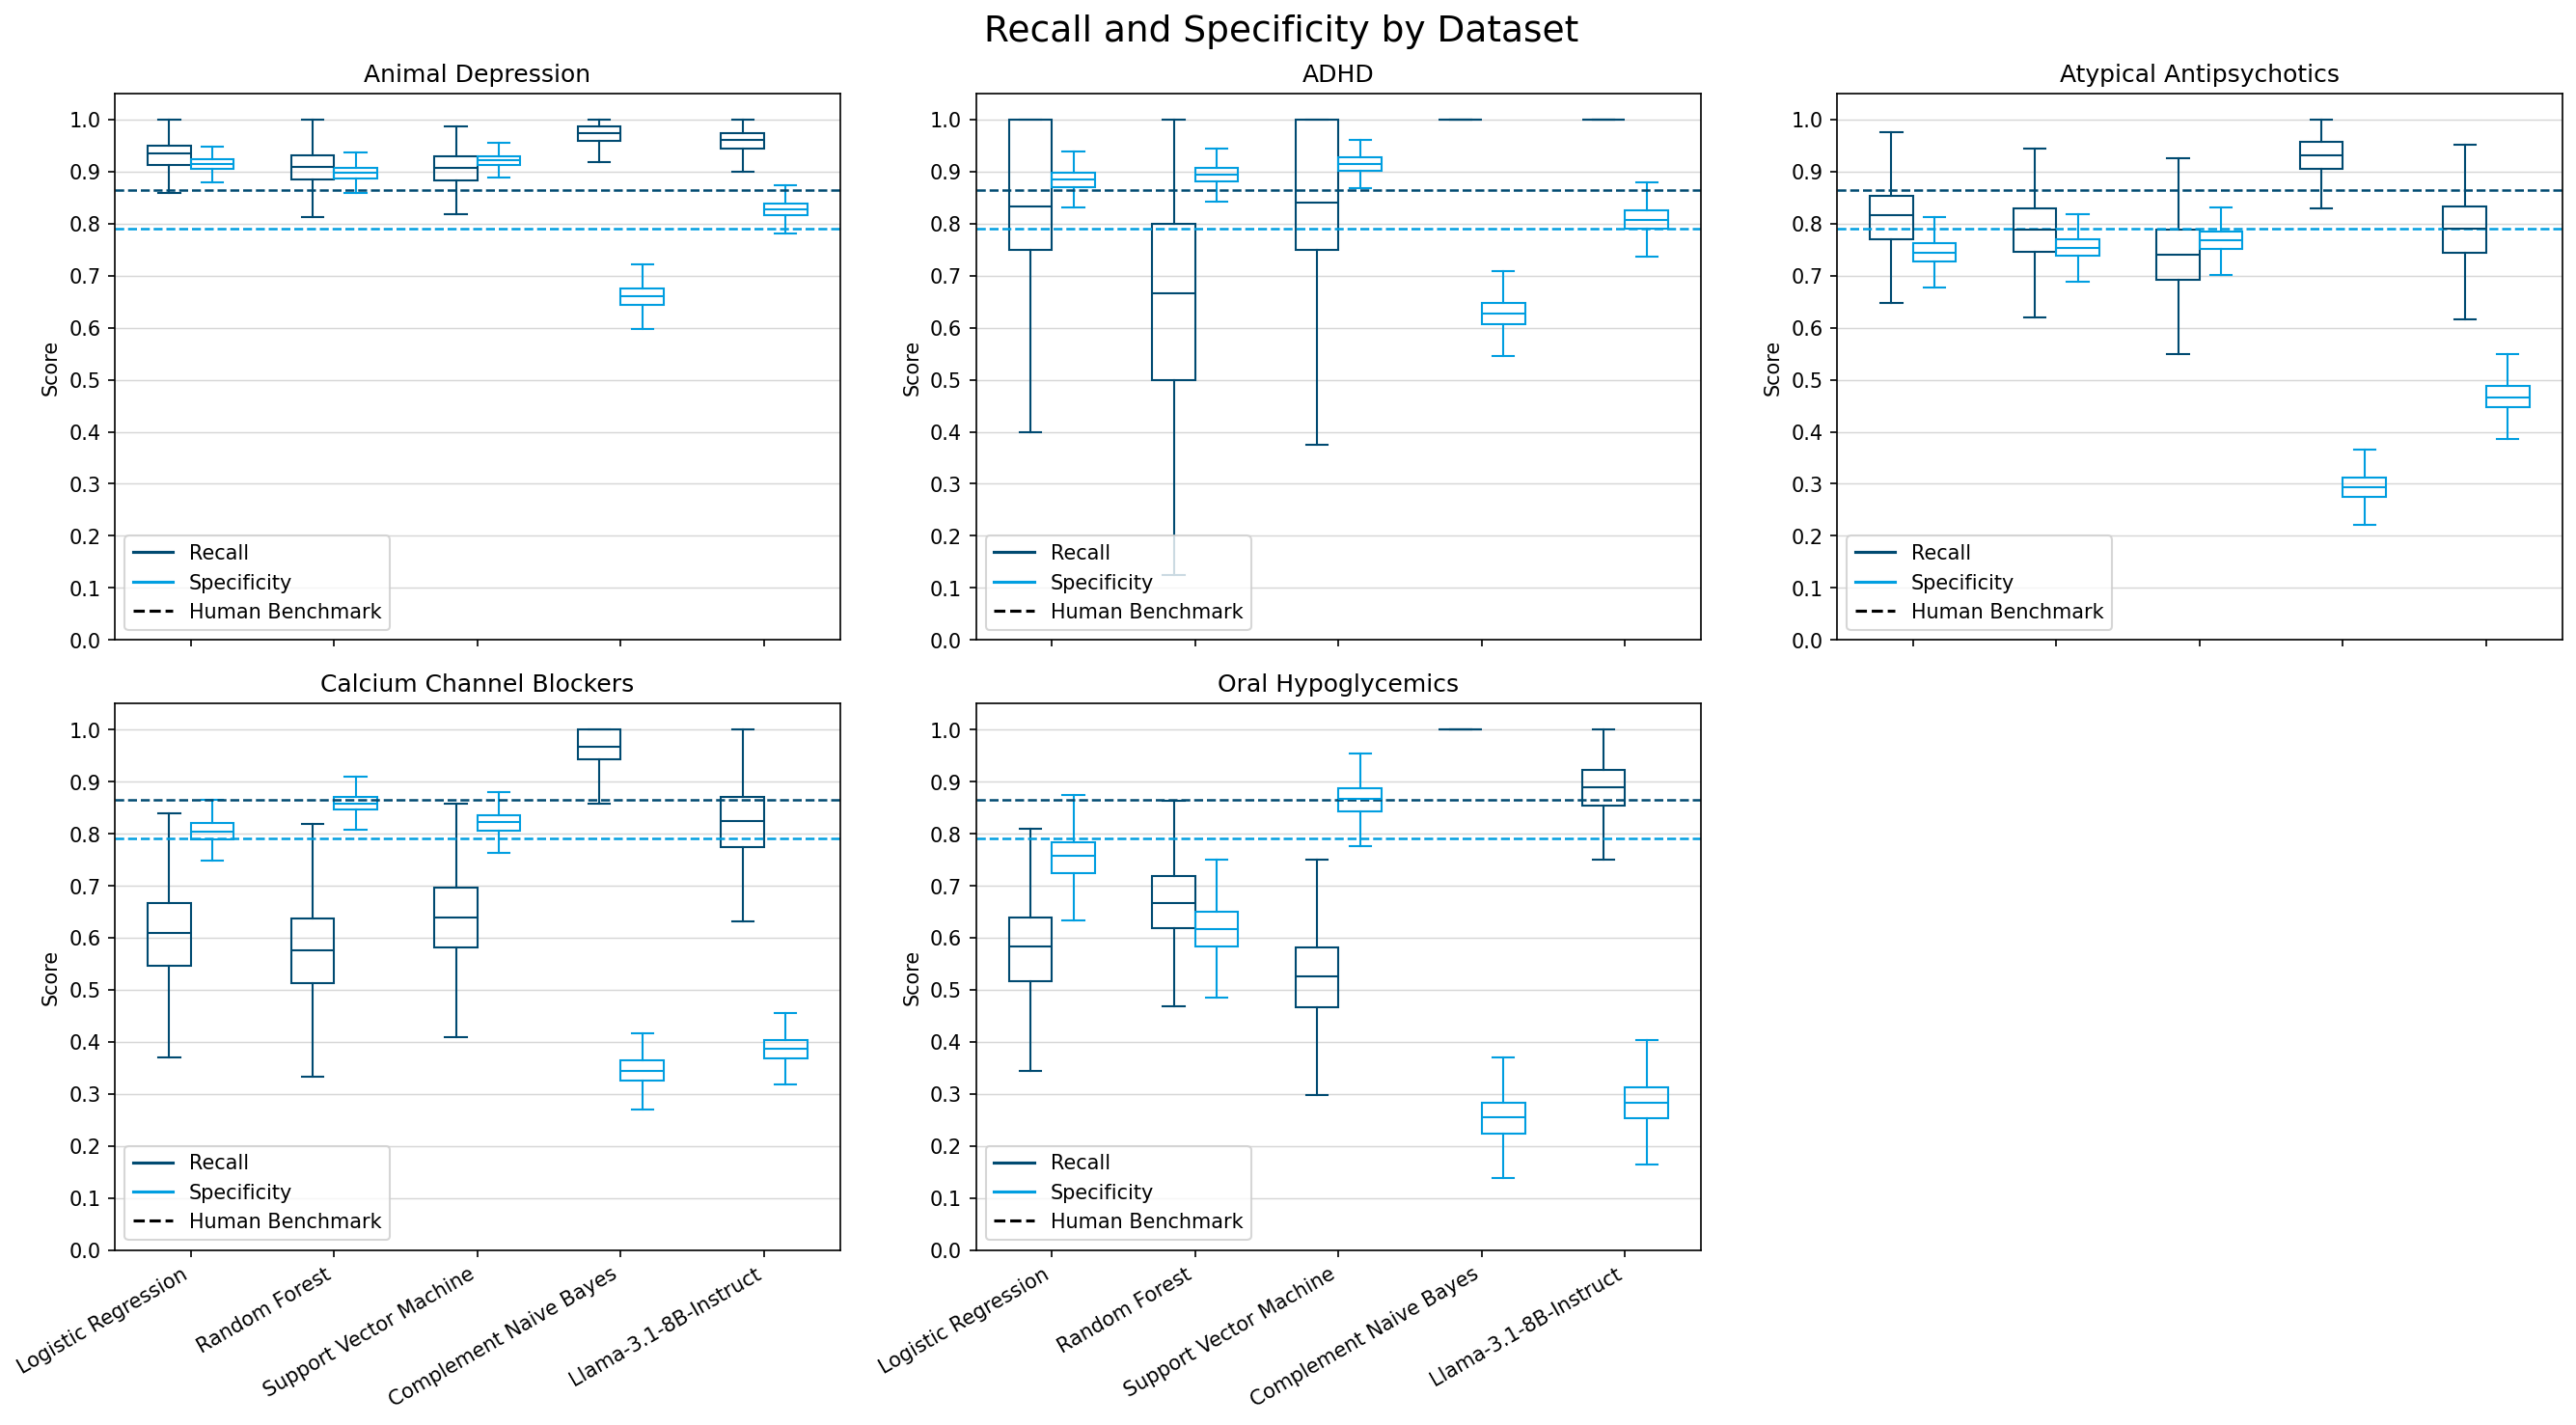

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10), dpi=150, sharex=True)
axes = axes.flatten()

# one subplot per dataset
# for each dataset, plot recall and specificity boxplots
for i, dataset in enumerate(datasets):
    
    # collect the scores for the current dataset in these lists
    # scores for each estimator are nested lists
    recall_scores, specificity_scores = [], []
    
    # plot recall and specificity scores for each estimator
    # across all bootstrap samples
    for est in estimators:
        recall_scores.append(results['datasets'][dataset][est]['bootstrap']['scores']['recall'])
        specificity_scores.append(results['datasets'][dataset][est]['bootstrap']['scores']['specificity'])
    
    # to arrange recall and specificity boxplots side by side
    positions = np.arange(len(estimators))
    
    # width of the individual boxplots
    width = 0.3 

    # Recall boxplots (left)
    bp1 = axes[i].boxplot(
        recall_scores,
        positions=positions - width/2,
        widths=width,
        patch_artist=True,
        showfliers=False,
        boxprops=dict(facecolor='none', edgecolor='#004a71', linewidth=1),
        medianprops=dict(color='#004a71', linewidth=1),
        whiskerprops=dict(color='#004a71', linewidth=1),
        capprops=dict(color='#004a71', linewidth=1),
        flierprops=dict(markerfacecolor='none', markeredgecolor='#004a71'),
        manage_ticks=False
    )

    # Specificity boxplots (right)
    bp2 = axes[i].boxplot(
        specificity_scores,
        positions=positions + width/2,
        widths=width,
        patch_artist=True,
        showfliers=False,
        boxprops=dict(facecolor='none', edgecolor='#009ee0', linewidth=1),
        medianprops=dict(color='#009ee0', linewidth=1),
        whiskerprops=dict(color='#009ee0', linewidth=1),
        capprops=dict(color='#009ee0', linewidth=1),
        flierprops=dict(markerfacecolor='none', markeredgecolor='#009ee0'),
        manage_ticks=False
    )
    # Human benchmark lines
    axes[i].axhline(human_recall, color='#004a71', linestyle='--', linewidth=1.2, )#label='Human Benchmark' if i == 0 else None)
    axes[i].axhline(human_specificity, color='#009ee0', linestyle='--', linewidth=1.2)
    
    # X-ticks and labels
    axes[i].set_xticks(positions)
    axes[i].set_xticklabels(estimator_labels, rotation=30, ha='right')
    axes[i].set_title(dataset_dict[dataset])
    axes[i].set_ylim(0, 1.05)
    axes[i].set_yticks(np.arange(0, 1.1, 0.1))
    axes[i].set_ylabel('Score')
    axes[i].grid(True, axis='y', linestyle='-', linewidth=0.7, alpha=0.5)
    
    # legend
    axes[i].plot([], [], color='#004a71', label='Recall')
    axes[i].plot([], [], color='#009ee0', label='Specificity')
    axes[i].axhline(-1, color='k', linestyle='--', label='Human Benchmark')  
    axes[i].legend(loc='lower left')

fig.suptitle('Recall and Specificity by Dataset', fontsize=18)

axes[5].set_visible(False)  # Hide the empty plot where the pancreatic surgery data would be

plt.tight_layout()
plt.savefig('recall specificity by dataset.svg', format='svg')
plt.show()

## All Scores
To efficiently plot the bootstrapped metric scores, store all scores within one big dataframe:

In [21]:
# Create a list to collect data
data = []

for dataset in results['datasets']:
    for estimator in results['datasets'][dataset]:
        for metric in results['datasets'][dataset][estimator]['bootstrap']['scores']:
            scores = results['datasets'][dataset][estimator]['bootstrap']['scores'][metric]

            for score in scores:
                data.append({'dataset': dataset, 'estimator': estimator, 'metric': metric, 'score': score})




# Create a DataFrame from the collected data
df = pl.DataFrame(data)

### All Scores by Dataset
Using this dataframe we draw an overview that lets us compare the performance of each estimator on each dataset individually:

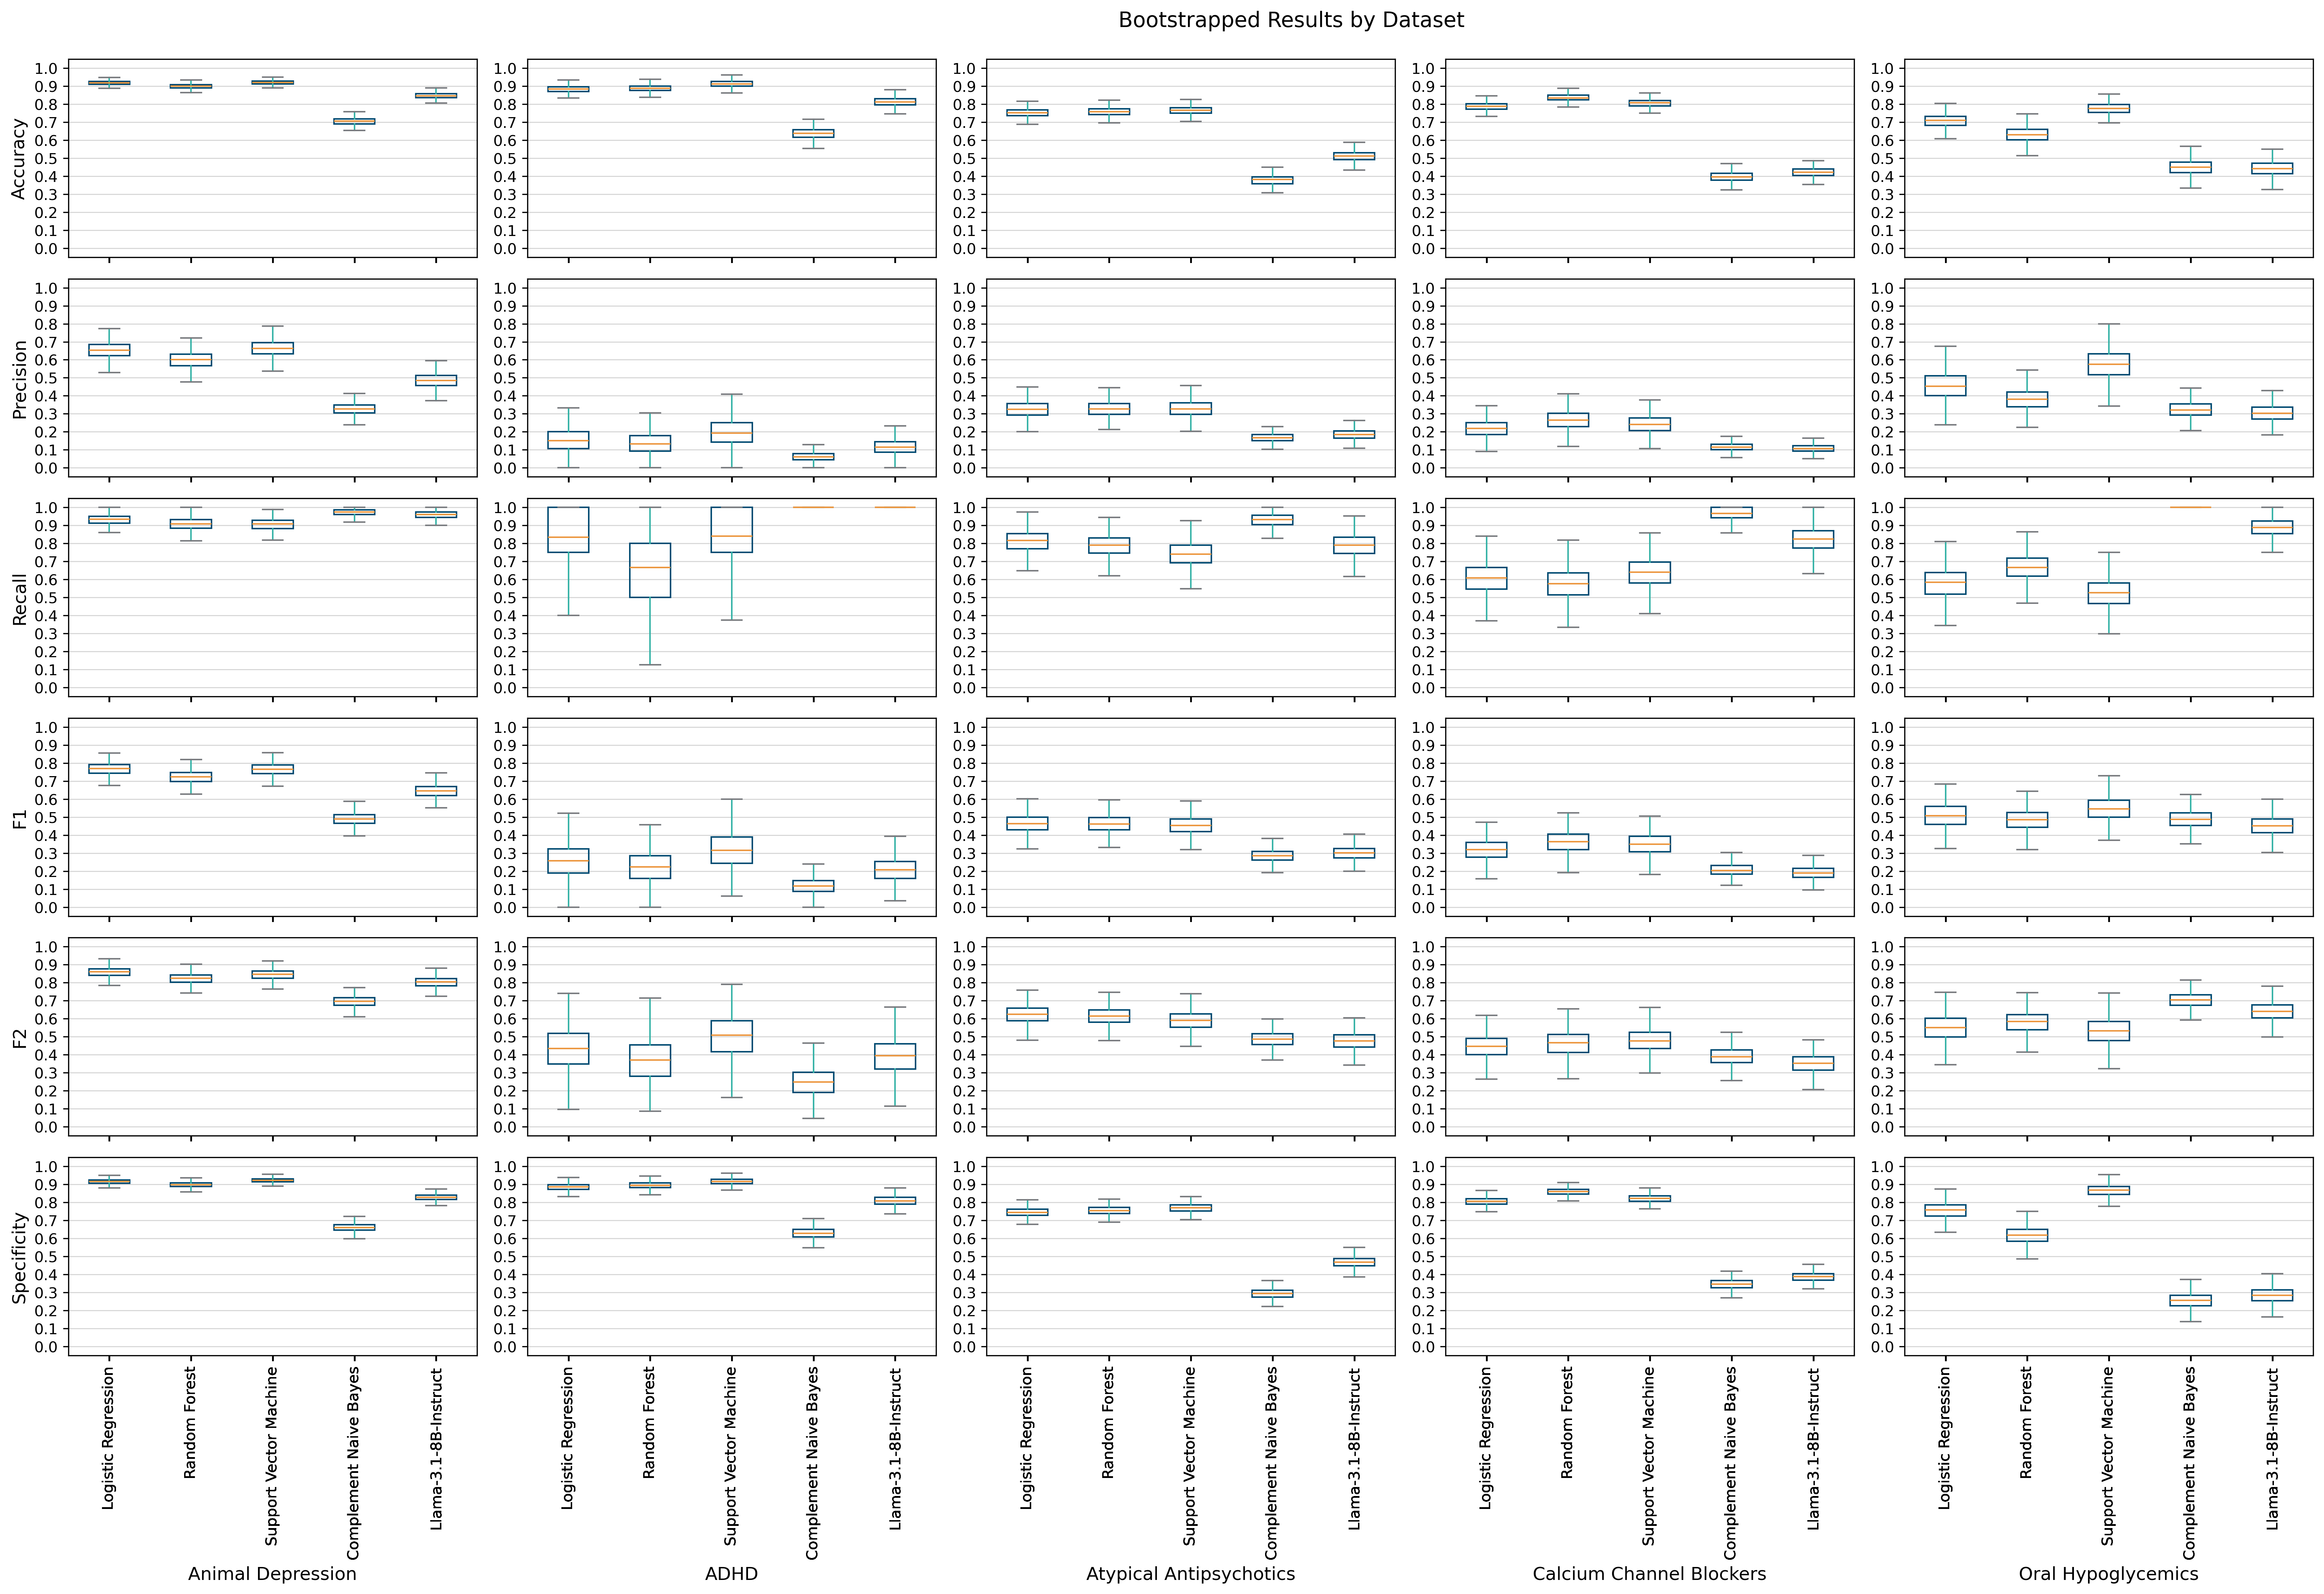

In [22]:
list_metrics = list(metrics.keys())

# Increase the width of the figure
fig, axes = plt.subplots(len(list_metrics), len(datasets), figsize=(24, 15), sharex=True, sharey=True, dpi=300)

for i, metric in enumerate(list_metrics):
    for j, dataset in enumerate(datasets):
        ax = axes[i, j]
        
        # Filter the data for the current metric and dataset
        df_filtered = df.filter(
            (pl.col('dataset') == dataset) & (pl.col('metric') == metric)
        ).to_pandas()
        
        # Create a list to hold the data for each estimator
        data = [df_filtered[df_filtered['estimator'] == estimator]['score'] for estimator in estimators]
        
        # Plot the boxplot using pyplot
        box = ax.boxplot(data, tick_labels=[estimator_dict[est] for est in estimators], showfliers=False, patch_artist=True)
        
        # Set custom colors for each box
        for patch in box['boxes']:
            patch.set_facecolor('none')
            patch.set_edgecolor(colors['boxes'])
        
        # Set custom colors for whiskers, caps, and medians
        for whisker in box['whiskers']:
            whisker.set_color(colors['whiskers'])
        for cap in box['caps']:
            cap.set_color(colors['caps'])
        for median in box['medians']:
            median.set_color(colors['medians'])
        
        # Remove the title of the subplot
        ax.set_title('')
        
        # Set the y-axis labels to the metrics for the first column
        if j == 0:
            ax.set_ylabel(metric.capitalize(), fontsize=12)
        
        # Set the x-axis labels to the datasets below the lowest subplot in each column
        if i == len(list_metrics) - 1:
            ax.set_xlabel(dataset_dict[dataset], fontsize=12)
        
        # Rotate the x-ticks by 90 degrees
        ax.tick_params(axis='x', rotation=90)
        
        # Ensure y-ticks are shown for each subplot
        ax.set_yticks([i * 0.1 for i in range(11)])  # Set y-ticks in steps of 0.1
        ax.yaxis.set_tick_params(which='both', labelleft=True)
        
        # Display grid lines for y-ticks
        ax.grid(True, axis='y', linestyle='-', linewidth=0.7, alpha=0.5)

plt.tight_layout(rect=[0, 0, 0.9, 0.96])
plt.suptitle('Bootstrapped Results by Dataset', fontsize=14)

# Save the figure as an SVG file
plt.savefig('evaluation_metrics_by_dataset.svg', format='svg')

plt.show()

### All Scores by Estimator
This overview enables us to compare side-by-side how each estimator compared across different datasets:

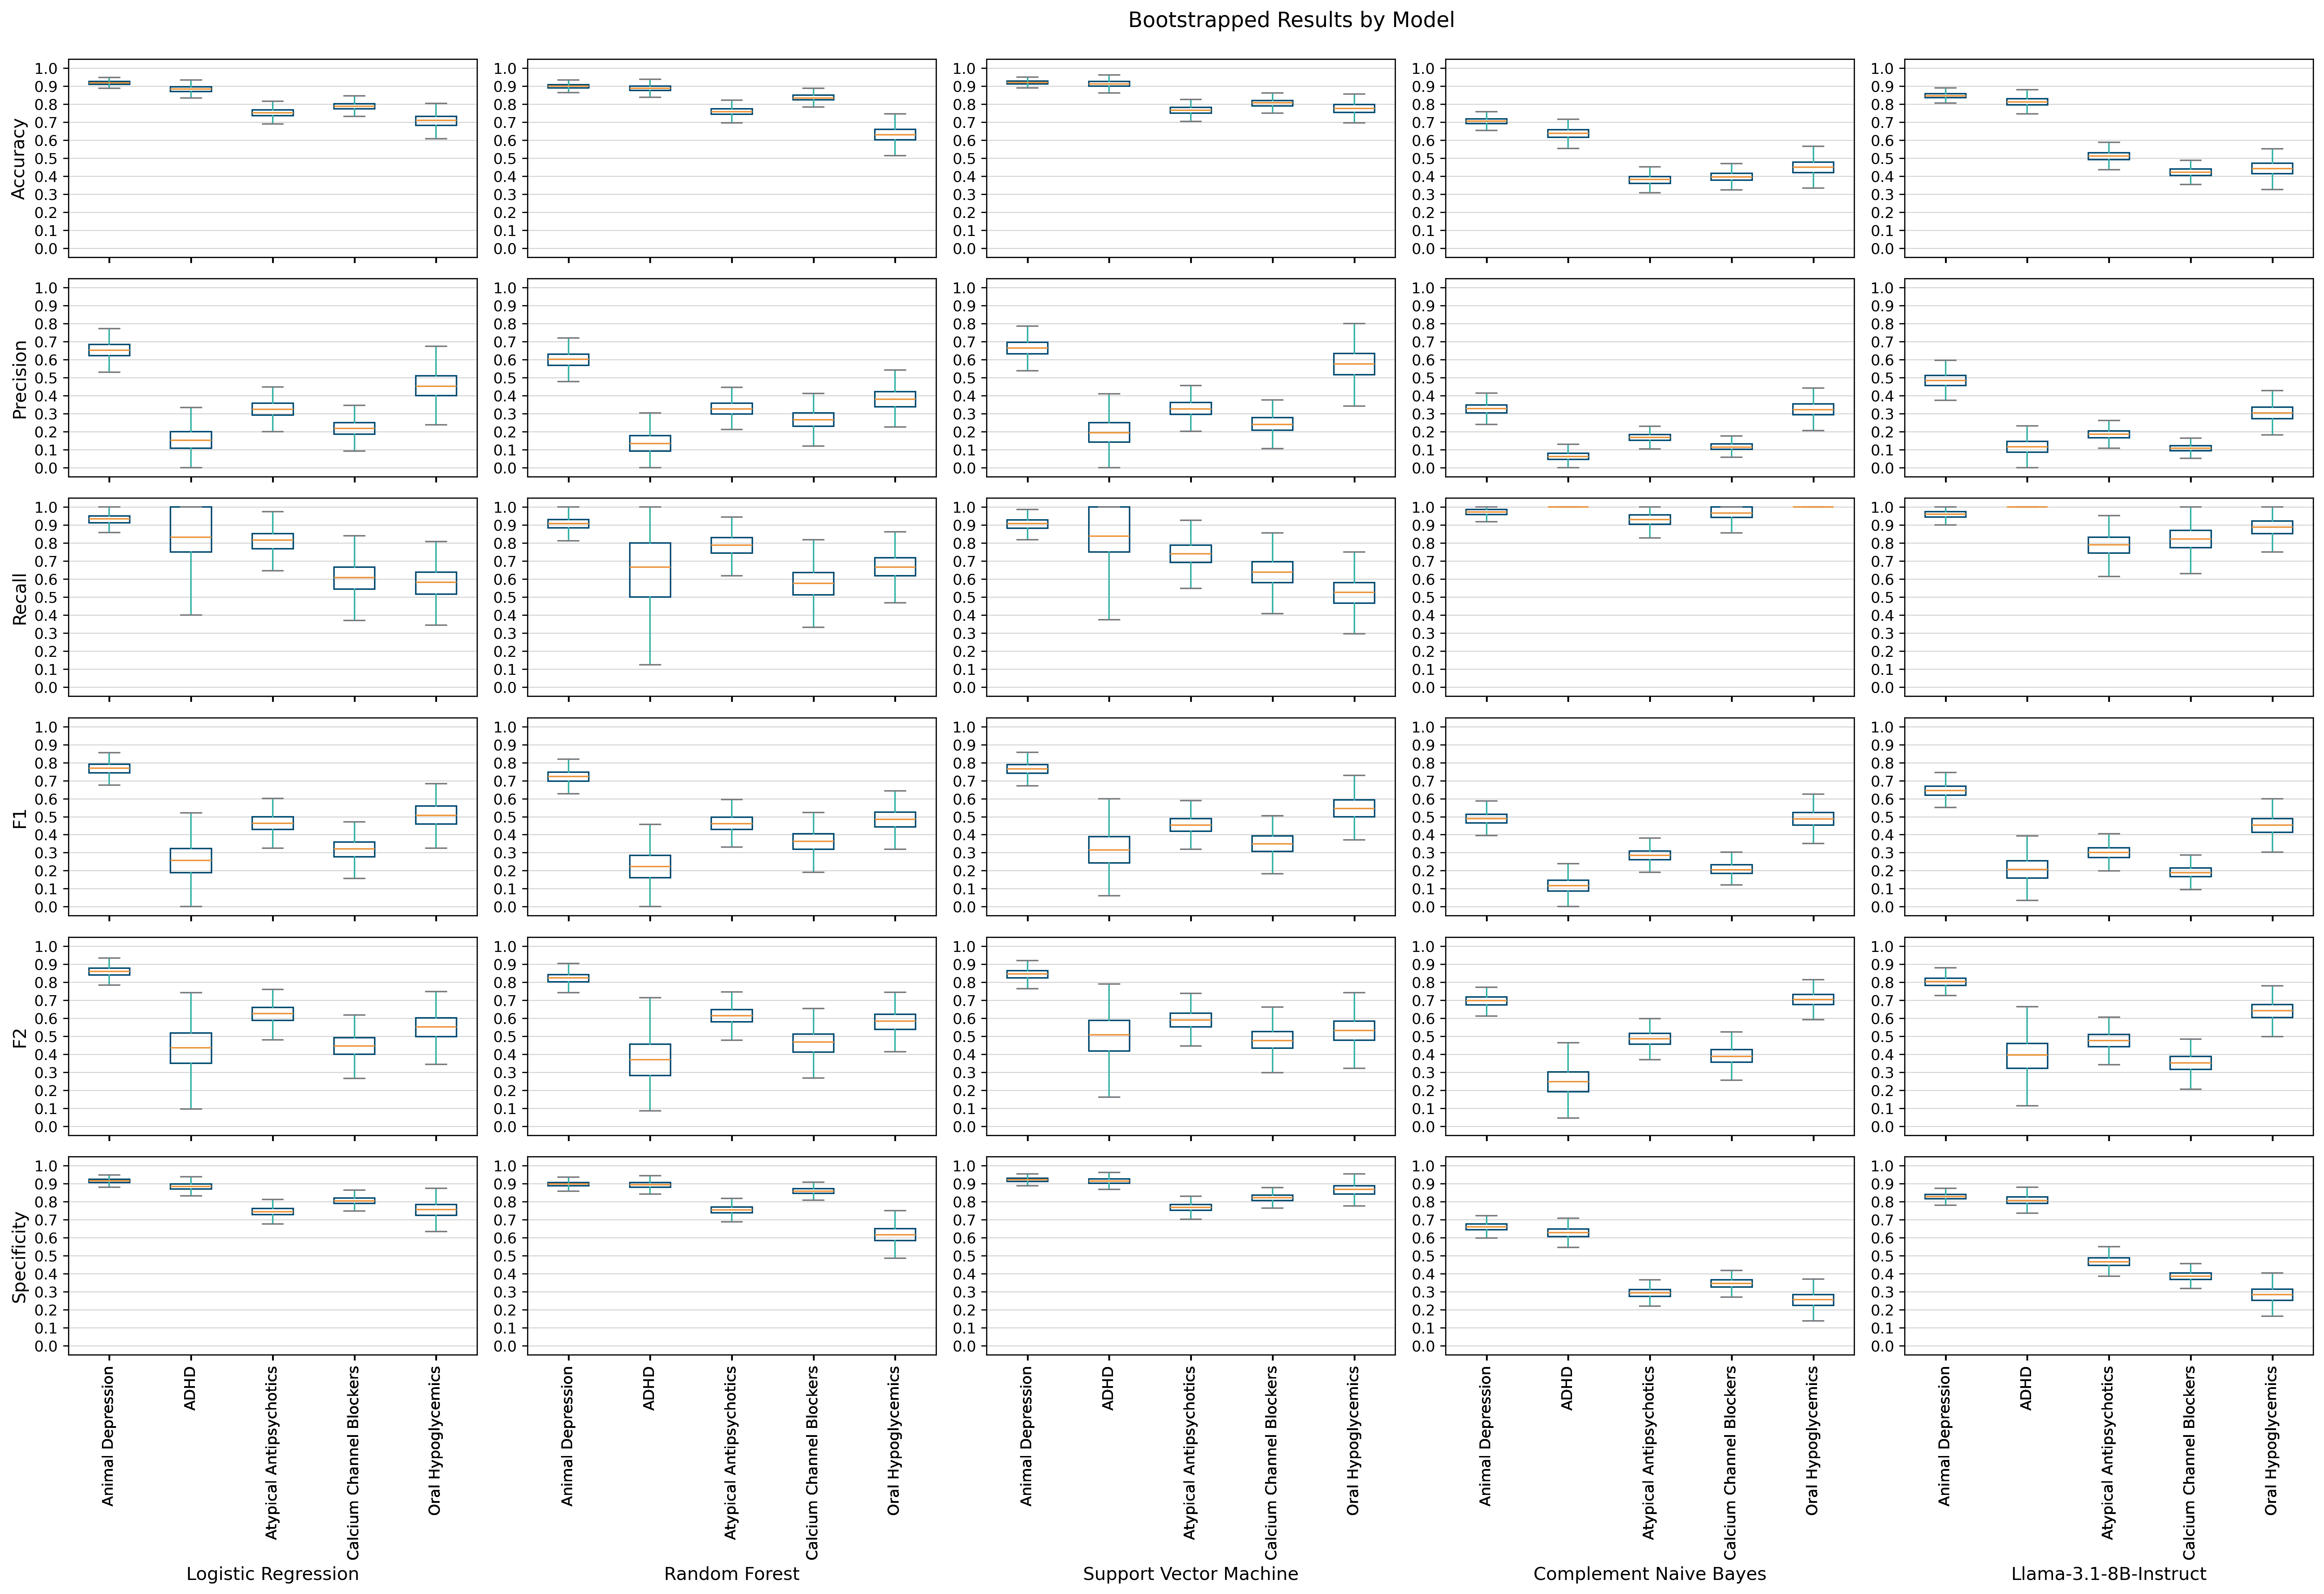

In [23]:
list_metrics = list(metrics.keys())
list_estimators = list(results['datasets'][datasets[0]].keys())

# Create a figure with subplots for each metric and estimator
fig, axes = plt.subplots(len(list_metrics), len(list_estimators), figsize=(24, 15), sharex=True, sharey=True, dpi=300)

for i, metric in enumerate(list_metrics):
    for j, estimator in enumerate(list_estimators):
        ax = axes[i, j]
        
        # Filter the data for the current metric and estimator
        df_filtered = df.filter(
            (pl.col('metric') == metric) & (pl.col('estimator') == estimator)
        ).to_pandas()
        
        # Create a list to hold the data for each dataset
        data = [df_filtered[df_filtered['dataset'] == dataset]['score'] for dataset in datasets]
        
        # Plot the boxplot using pyplot
        box = ax.boxplot(data, tick_labels=[dataset_dict[ds] for ds in datasets], showfliers=False, patch_artist=True)
        
        # Set custom colors for each box
        for patch in box['boxes']:
            patch.set_facecolor('none')
            patch.set_edgecolor(colors['boxes'])
        
        # Set custom colors for whiskers, caps, and medians
        for whisker in box['whiskers']:
            whisker.set_color(colors['whiskers'])
        for cap in box['caps']:
            cap.set_color(colors['caps'])
        for median in box['medians']:
            median.set_color(colors['medians'])
        
        # Remove the title of the subplot
        ax.set_title('')
        
        # Set the y-axis labels to the metrics for the first column
        if j == 0:
            ax.set_ylabel(metric.capitalize(), fontsize=12)
        
        # Set the x-axis labels to the estimators below the lowest subplot in each column
        if i == len(list_metrics) - 1:
            ax.set_xlabel(estimator_dict[estimator], fontsize=12)
        
        # Rotate the x-ticks by 90 degrees
        ax.tick_params(axis='x', rotation=90)
        
        # Set ticks of 0.1
        ax.set_yticks([i * 0.1 for i in range(11)])  # Set y-ticks in steps of 0.1

        # Ensure y-ticks are shown for each subplot
        ax.yaxis.set_tick_params(which='both', labelleft=True)
        
        # Display grid lines for y-ticks
        ax.grid(True, axis='y', linestyle='-', linewidth=0.7, alpha=0.5)

plt.tight_layout(rect=[0, 0, 0.9, 0.96])
plt.suptitle('Bootstrapped Results by Model', fontsize=14)

# Save the figure as an SVG file
plt.savefig('evaluation_metrics_by_estimator.svg', format='svg')

plt.show()